# Notebook 02 -- Cluster-then-Reduce

Notebook 01 reduces first (PCA to 90% variance) and clusters the reduced space. This
notebook does the mirror: it clusters the **full preprocessed feature space** of the
cleaned UNSW-NB15 training partition and only afterwards projects the result to 2D for
visual inspection. Together the pair answers one question neither notebook answers
alone: is the unsupervised structure of UNSW-NB15 a property of the data, or an
artefact of the reduction that preceded the clustering?

## Five questions this notebook answers

1. Which of four algorithms (K-Means, Ward agglomerative, DBSCAN, spectral) recovers
   structure in the untouched feature space, scored by silhouette, Calinski-Harabasz
   and Davies-Bouldin?
2. How far does that structure align with `attack_cat` and `label`, measured by
   Adjusted Rand Index (ARI), Normalised Mutual Information (NMI) and a contingency
   table?
3. Is the chosen partition stable under resampling (pairwise ARI over bootstrap
   reruns)?
4. Do cluster-then-reduce and reduce-then-cluster reach the same conclusion on the
   same metrics?
5. Does removing the `sttl` / `ct_state_ttl` testbed shortcut change any of the above?

No `fit`, `fit_transform` or `fit_predict` in this notebook ever receives `attack_cat`
or `label`. Two runtime assertion cells prove it.

## How to re-run

```
uv run jupyter nbconvert --to notebook --execute --inplace \
    --ExecutePreprocessor.timeout=-1 notebooks/02_clustering_reduction.ipynb
```


## Compute budget

All clustering below runs on a seed-42 stratified subsample of the training partition
(at most 10,000 rows, floor 50 per class) -- never on the full partition. `n_jobs=-1`
is passed wherever the estimator accepts it; `KMeans` and the Ward `linkage` step do
not accept `n_jobs` in scikit-learn 1.9, which is expected, not a bug.

| Step | Rows | Cap mechanism | Estimated time |
|---|---|---|---|
| Preprocess, 2 variants | 10,000 | stratified subsample | < 5 s |
| K-Means sweep, 11 k values x 2 variants | 10,000 | `n_init=10, random_state=42` | ~30 s |
| Ward | 10,000 | one `scipy.cluster.hierarchy.linkage` per variant, `fcluster` per k | ~2 min |
| DBSCAN + k-distance | 10,000 | `NearestNeighbors(n_jobs=-1)`, `DBSCAN(n_jobs=-1)` | ~30 s |
| Spectral | 5,000 | nested stratified subsample, `n_jobs=-1` | ~2 min |
| PCA / t-SNE / UMAP, 2 variants | 10,000 | one embedding per variant, reused for both colourings | ~4 min |
| Silhouette / Calinski-Harabasz / Davies-Bouldin | <= 10,000 | direct | ~40 s |
| Trustworthiness | 2,000 | nested slice of the subsample | ~15 s |
| Bootstrap stability | 5 x 8,000 | K-Means only | ~30 s |

Target: under approximately 15 minutes on 16 threads.


In [1]:
%matplotlib inline
import json
import logging
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.cluster import DBSCAN, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors

from nids import paths
from nids.columns import feature_columns
from nids.data import load_clean_partitions
from nids.preprocessing import build_preprocessor_pair
from nids.results import ResultsWriter
from nids.sampling import stratified_subsample

logging.basicConfig(level=logging.INFO)

NOTEBOOK_ID = "clustering_reduction"
SEED = 42
MAX_ROWS = 10_000
FLOOR = 50
SPECTRAL_MAX_ROWS = 5_000
K_RANGE = range(2, 13)
BOOTSTRAP_REPEATS = 5
BOOTSTRAP_FRACTION = 0.8
TRUSTWORTHINESS_ROWS = 2_000
VARIANTS = ("with_ttl", "without_ttl")

START_TIME = time.time()


/home/pato/Desktop/machine_learning_project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# No name ever binds the CleaningResult or its .test frame -- only .train is kept.
train = load_clean_partitions().train.reset_index(drop=True)
print(f"Training partition: {len(train)} rows.")


Training partition: 107740 rows.


In [3]:
sub = stratified_subsample(train, stratify_by="attack_cat", max_rows=MAX_ROWS, floor=FLOOR, seed=SEED)
SUB = sub.data
print(f"Subsample: {len(SUB)} rows across {SUB['attack_cat'].nunique()} attack_cat classes.")


Subsample: 10000 rows across 10 attack_cat classes.


In [4]:
# attack_cat/label are held separately: stratification, colouring and post-hoc
# external validation only -- never a fit.
y_cat = SUB["attack_cat"].to_numpy()
y_bin = SUB["label"].to_numpy()
index_frame = SUB[["attack_cat", "label"]].assign(position=np.arange(len(SUB)))


In [5]:
pipes = build_preprocessor_pair()
cols_by_variant = {v: feature_columns(include_ttl=(v == "with_ttl")) for v in VARIANTS}
X = {}
for v in VARIANTS:
    cols = cols_by_variant[v]
    pipes[v].fit(SUB[cols])
    X[v] = pipes[v].transform(SUB[cols])


In [6]:
feature_space_rows = []
for v in VARIANTS:
    feature_space_rows.append(
        {"variant": v, "rows": int(X[v].shape[0]), "columns": int(X[v].shape[1])}
    )
feature_space_shape_df = pd.DataFrame(feature_space_rows)
print(feature_space_shape_df)


       variant   rows  columns
0     with_ttl  10000       52
1  without_ttl  10000       50


In [7]:
# Assertion 1: the test partition is never bound, and no unexpected DataFrame exists yet.
assert "cleaned" not in globals()
assert "test" not in globals()
_allowed_frames = {"train", "SUB", "index_frame", "feature_space_shape_df"}
_disallowed_frames = [
    name
    for name, value in list(globals().items())
    if isinstance(value, pd.DataFrame)
    and name not in _allowed_frames
    and not name.startswith("_")  # exclude IPython's own output-history bindings (_, _6, ...)
]
assert not _disallowed_frames, f"Unexpected DataFrame globals bound before clustering: {_disallowed_frames}"

for v in VARIANTS:
    # Assertion 2: targets never enter feature_columns.
    assert set(cols_by_variant[v]).isdisjoint({"attack_cat", "label"}), (
        f"Target leaked into feature_columns for variant {v!r}."
    )
    # Assertion 3: targets never survive into the fitted pipeline's output columns.
    feature_names_out = set(pipes[v].get_feature_names_out())
    assert not ({"attack_cat", "label"} & feature_names_out), (
        f"Target leaked into fitted pipeline output for variant {v!r}."
    )
    # Assertion 4: shape and finiteness of the design matrix.
    assert X[v].shape[0] == len(SUB)
    assert np.isfinite(X[v]).all(), f"Non-finite value in the preprocessed matrix for variant {v!r}."

# Assertion 5: the subsample was drawn with the declared parameters.
assert sub.seed == SEED
assert sub.requested_max_rows == MAX_ROWS
assert sub.floor == FLOOR

print(
    "All five runtime assertions passed: no test partition bound, no target leakage, "
    "finite features, expected subsample parameters."
)


All five runtime assertions passed: no test partition bound, no target leakage, finite features, expected subsample parameters.


In [8]:
def finite(value):
    """Convert a metric value to a JSON-safe, finite representation.

    Non-finite floats become the strings "inf", "-inf" or "nan" instead of a
    floating-point infinity or NaN, which json.dumps cannot emit.
    """
    if isinstance(value, str):
        return value
    if isinstance(value, (int, np.integer)) and not isinstance(value, bool):
        return int(value)
    fvalue = float(value)
    if math.isnan(fvalue):
        return "nan"
    if math.isinf(fvalue):
        return "inf" if fvalue > 0 else "-inf"
    return fvalue


metrics_log = {}


def record_metric(name, value, description):
    """Register one metric with `writer` and mirror it in `metrics_log`."""
    safe_value = finite(value)
    writer.add_metric(name, safe_value, description)
    metrics_log[name] = safe_value
    return safe_value


def record_note(note_id, text):
    """Register one note with `writer`."""
    writer.add_note(note_id, text)


def internal_metrics(matrix, labels):
    """Silhouette, Calinski-Harabasz and Davies-Bouldin for one clustering.

    Points with a negative label (DBSCAN noise) are excluded from scoring.
    The three score fields become "nan" when fewer than two clusters remain
    among the scored points; n_clusters and n_rows_scored always stay numeric.
    """
    labels = np.asarray(labels)
    mask = labels >= 0
    scored_labels = labels[mask]
    unique_labels = np.unique(scored_labels)
    n_clusters = int(len(unique_labels))
    n_rows_scored = int(mask.sum())
    if n_clusters < 2:
        return {
            "silhouette": "nan",
            "calinski_harabasz": "nan",
            "davies_bouldin": "nan",
            "n_clusters": n_clusters,
            "n_rows_scored": n_rows_scored,
        }
    scored_matrix = matrix[mask]
    return {
        "silhouette": float(silhouette_score(scored_matrix, scored_labels)),
        "calinski_harabasz": float(calinski_harabasz_score(scored_matrix, scored_labels)),
        "davies_bouldin": float(davies_bouldin_score(scored_matrix, scored_labels)),
        "n_clusters": n_clusters,
        "n_rows_scored": n_rows_scored,
    }


def _silhouette_sort_key(silhouette, tiebreak):
    score = silhouette if isinstance(silhouette, float) else float("-inf")
    return (-score, tiebreak)


def best_k_by_silhouette(rows, variant):
    """Argmax silhouette over the swept k values for one variant, ties -> smaller k."""
    candidates = [row for row in rows if row["variant"] == variant]
    return min(candidates, key=lambda row: _silhouette_sort_key(row["silhouette"], row["k"]))["k"]


VARIANT_COLOURS = {"with_ttl": "#1f77b4", "without_ttl": "#ff7f0e"}


def new_figure(nrows=1, ncols=1, figsize=None, suptitle=None):
    """Create a figure/axes grid with the notebook's shared style."""
    if figsize is None:
        figsize = (6.5 * ncols, 4.5 * nrows)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    if suptitle:
        fig.suptitle(suptitle)
    return fig, axes


_classes_sorted = sorted(str(value) for value in SUB["attack_cat"].unique())
_class_cmap_name = "tab10" if len(_classes_sorted) <= 10 else "tab20"
_class_cmap = plt.get_cmap(_class_cmap_name)
CLASS_COLOURS = {
    cls: _class_cmap.colors[i % len(_class_cmap.colors)] for i, cls in enumerate(_classes_sorted)
}


def select_eps(sample, min_samples):
    """Deterministic DBSCAN eps from the normalised-chord knee of the k-distance curve.

    Returns (eps, rule_used, kdist); kdist is reused by the k-distance figure so the
    neighbour search never runs twice.
    """
    k = min_samples
    neighbours = NearestNeighbors(n_neighbors=k, n_jobs=-1).fit(sample)
    distances, _ = neighbours.kneighbors(sample)
    kdist = np.sort(distances[:, k - 1])
    m = kdist.size
    x = np.arange(m, dtype=np.float64) / (m - 1)
    span = kdist[-1] - kdist[0]
    if span == 0:
        return float(np.median(kdist)), "degenerate_flat_curve", kdist
    y = (kdist - kdist[0]) / span
    dx, dy = x[-1] - x[0], y[-1] - y[0]
    perp = np.abs(dy * (x - x[0]) - dx * (y - y[0])) / np.hypot(dx, dy)
    eps = float(kdist[int(np.argmax(perp))])
    if eps <= 0:
        positive = kdist[kdist > 0]
        if positive.size == 0:
            return 0.0, "no_positive_distance", kdist
        return float(positive.min()), "degenerate_zero_knee", kdist
    return eps, "chord", kdist


In [9]:
writer = ResultsWriter(NOTEBOOK_ID)
print("Results directory:", writer.directory)

writer.add_table(
    sub.to_frame(),
    name="subsample_allocation",
    title="Stratified subsample allocation per attack category",
    description=(
        "Realised row allocation per attack_cat class for the seed-42 stratified "
        "subsample, against the pure-proportional reference."
    ),
    sort_by=["label"],
)

attack_cat_class_sizes_df = (
    SUB["attack_cat"].value_counts().rename_axis("attack_cat").reset_index(name="count")
)
writer.add_table(
    attack_cat_class_sizes_df,
    name="attack_cat_class_sizes",
    title="Attack category sizes in the subsample",
    description="Row count per attack_cat class in the 10,000-row stratified subsample.",
    sort_by=["attack_cat"],
)

writer.add_table(
    feature_space_shape_df,
    name="feature_space_shape",
    title="Preprocessed feature space shape per variant",
    description="Row and column count of the preprocessed design matrix for each TTL variant.",
    sort_by=["variant"],
)

record_metric(
    "subsample_rows", len(SUB),
    "Rows in the seed-42 stratified subsample used for every clustering call in this notebook.",
)
record_metric(
    "subsample_classes", int(SUB["attack_cat"].nunique()),
    "Number of attack_cat classes present in the subsample.",
)
record_metric(
    "features_with_ttl", int(X["with_ttl"].shape[1]),
    "Preprocessed feature count for the with_ttl variant.",
)
record_metric(
    "features_without_ttl", int(X["without_ttl"].shape[1]),
    "Preprocessed feature count for the without_ttl variant.",
)


Results directory: /home/pato/Desktop/machine_learning_project/results/clustering_reduction


50

## 1. K-Means in the full feature space

Swept over `k = 2..12`: this notebook's own choice, stated here rather than derived --
it brackets the 10 `attack_cat` classes from both sides and matches notebook 01's grid
so the two notebooks' comparison shares one x-axis. `k*` is the k with the highest
silhouette, ties broken by the smaller k.


In [10]:
kmeans_rows = []
kmeans_labels_by_k = {v: {} for v in VARIANTS}
for v in VARIANTS:
    for k in K_RANGE:
        model = KMeans(n_clusters=k, n_init=10, random_state=SEED)
        labels = model.fit_predict(X[v])
        kmeans_labels_by_k[v][k] = labels
        metrics = internal_metrics(X[v], labels)
        kmeans_rows.append({"variant": v, "k": k, **metrics})

kmeans_k_sweep_df = pd.DataFrame(kmeans_rows)


In [11]:
k_star = {v: best_k_by_silhouette(kmeans_rows, v) for v in VARIANTS}
k_star


{'with_ttl': 12, 'without_ttl': 2}

In [12]:
kmeans_table_df = kmeans_k_sweep_df.copy()
for col in ["silhouette", "calinski_harabasz", "davies_bouldin"]:
    kmeans_table_df[col] = kmeans_table_df[col].apply(finite)

writer.add_table(
    kmeans_table_df,
    name="kmeans_k_sweep_metrics",
    title="K-Means internal metrics by number of clusters",
    description=(
        "Silhouette, Calinski-Harabasz and Davies-Bouldin scores for K-Means across the "
        "swept k range (2-12), for both TTL variants."
    ),
    sort_by=["variant", "k"],
)


PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/tables/kmeans_k_sweep_metrics.csv')

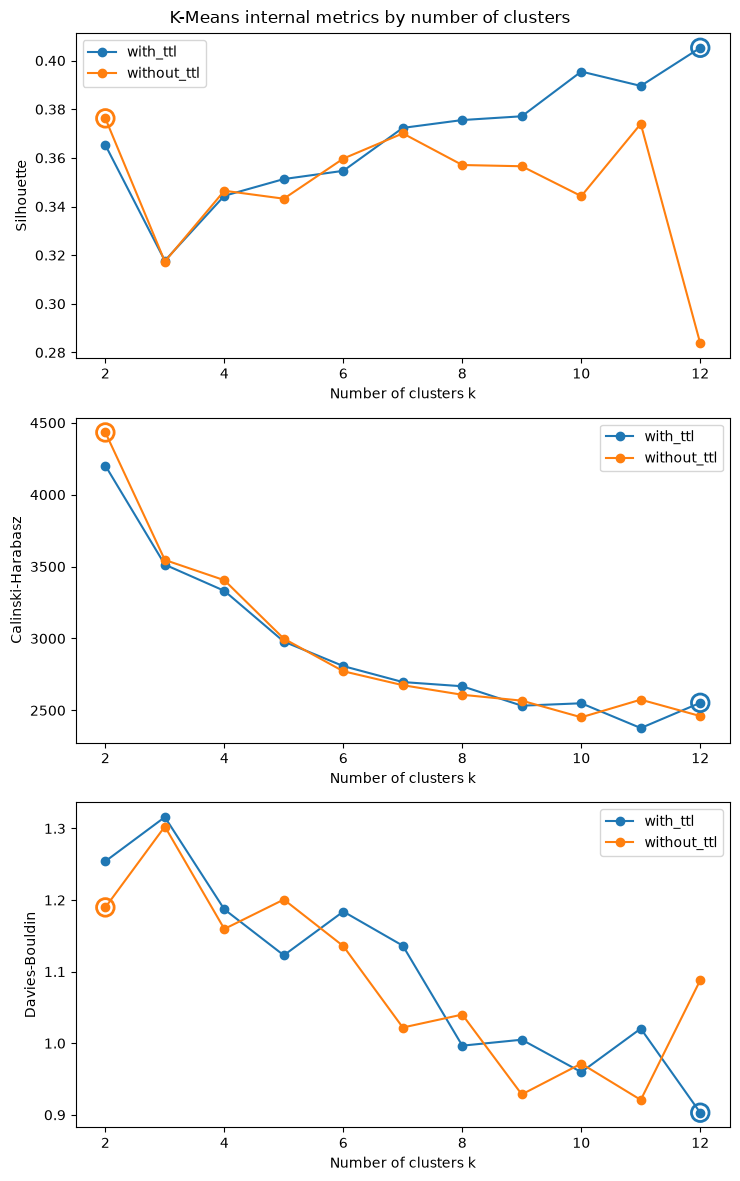

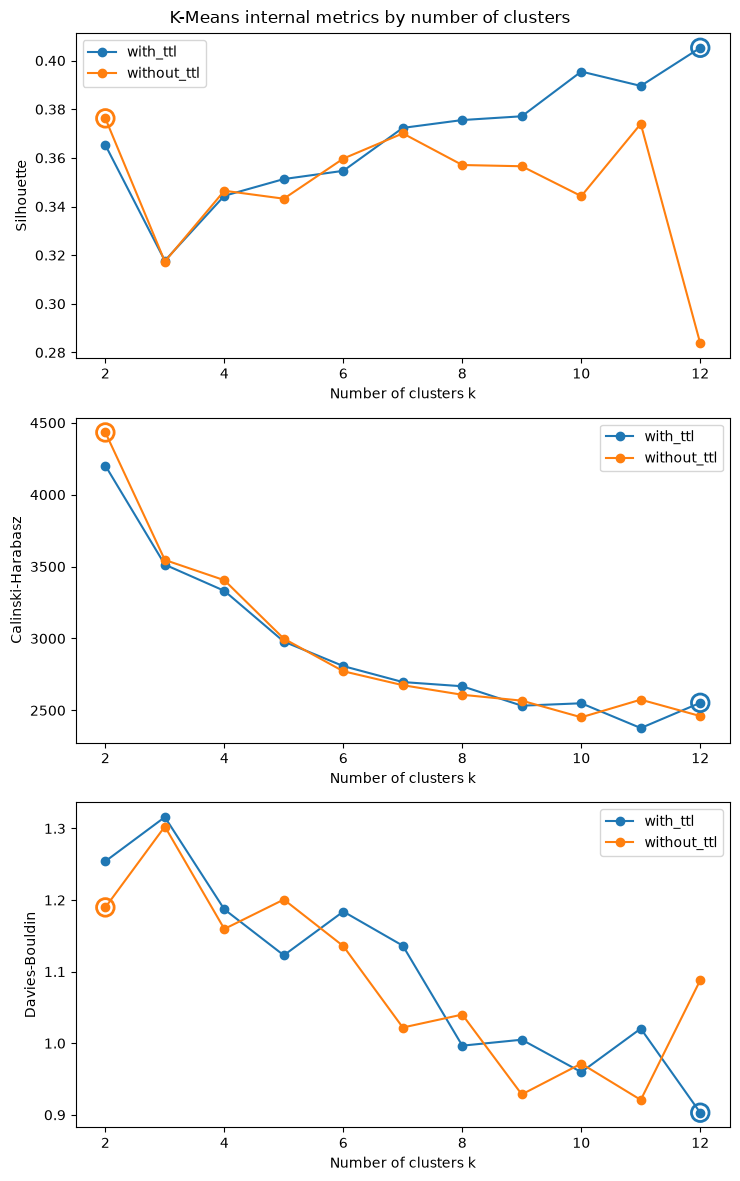

In [13]:
def sweep_metrics_figure(df, selected_k, title, description, name):
    fig, axes = new_figure(nrows=3, ncols=1, figsize=(7.5, 12))
    metric_panels = [
        ("silhouette", "Silhouette"),
        ("calinski_harabasz", "Calinski-Harabasz"),
        ("davies_bouldin", "Davies-Bouldin"),
    ]
    for ax, (column, label) in zip(axes, metric_panels):
        for v in VARIANTS:
            variant_df = df[df["variant"] == v].sort_values("k")
            ax.plot(variant_df["k"], variant_df[column], marker="o", label=v, color=VARIANT_COLOURS[v])
            marked = variant_df[variant_df["k"] == selected_k[v]]
            if not marked.empty:
                ax.scatter(
                    marked["k"], marked[column], s=160, facecolors="none",
                    edgecolors=VARIANT_COLOURS[v], linewidths=2, zorder=5,
                )
        ax.set_xlabel("Number of clusters k")
        ax.set_ylabel(label)
        ax.legend()
    fig.suptitle(title)
    fig.tight_layout()
    writer.add_figure(fig, name=name, title=title, description=description)
    return fig


sweep_metrics_figure(
    kmeans_k_sweep_df,
    k_star,
    "K-Means internal metrics by number of clusters",
    (
        "Silhouette, Calinski-Harabasz and Davies-Bouldin against k for K-Means, both TTL "
        "variants; the ringed marker is the selected k*."
    ),
    "kmeans_internal_metrics_by_k",
)


In [14]:
kmeans_labels = {v: kmeans_labels_by_k[v][k_star[v]] for v in VARIANTS}

for v in VARIANTS:
    row = kmeans_k_sweep_df[
        (kmeans_k_sweep_df["variant"] == v) & (kmeans_k_sweep_df["k"] == k_star[v])
    ].iloc[0]
    record_metric(
        f"kmeans_selected_k_{v}", int(k_star[v]),
        f"K-Means k* selected by argmax silhouette for variant {v}.",
    )
    record_metric(
        f"kmeans_silhouette_at_selected_k_{v}", row["silhouette"],
        f"K-Means silhouette at k* for variant {v}.",
    )


## 2. Ward agglomerative clustering

Computed as **one** `scipy.cluster.hierarchy.linkage` per variant, then cut at every k
in the same range via `fcluster(..., criterion="maxclust")` -- never refit per k. On a
`MemoryError` this falls back to a nested 5,000-row stratified subsample and records a
note; the two variants can therefore end up scored on different row counts, both
declared in the table.


In [15]:
ward_Z = {}
ward_rows_positions = {}
for v in VARIANTS:
    try:
        ward_Z[v] = linkage(X[v], method="ward")
        ward_rows_positions[v] = np.arange(len(SUB))
    except MemoryError:
        nested = stratified_subsample(
            index_frame, stratify_by="attack_cat", max_rows=5_000, floor=FLOOR, seed=SEED
        )
        positions = nested.data["position"].to_numpy()
        ward_rows_positions[v] = positions
        ward_Z[v] = linkage(X[v][positions], method="ward")
        record_note(
            "ward_reduced_to_five_thousand_rows",
            f"Ward linkage for variant {v} raised a MemoryError on the full 10,000-row "
            "subsample; recomputed on a nested 5,000-row stratified subsample (seed 42).",
        )


In [16]:
ward_rows = []
ward_labels_by_k = {v: {} for v in VARIANTS}
for v in VARIANTS:
    ward_X = X[v][ward_rows_positions[v]]
    for k in K_RANGE:
        labels = fcluster(ward_Z[v], t=k, criterion="maxclust") - 1
        ward_labels_by_k[v][k] = labels
        metrics = internal_metrics(ward_X, labels)
        ward_rows.append({"variant": v, "k": k, **metrics})

ward_k_sweep_df = pd.DataFrame(ward_rows)


In [17]:
ward_k_star = {v: best_k_by_silhouette(ward_rows, v) for v in VARIANTS}
ward_k_star


{'with_ttl': 11, 'without_ttl': 2}

In [18]:
ward_table_df = ward_k_sweep_df.copy()
for col in ["silhouette", "calinski_harabasz", "davies_bouldin"]:
    ward_table_df[col] = ward_table_df[col].apply(finite)

writer.add_table(
    ward_table_df,
    name="ward_k_sweep_metrics",
    title="Ward agglomerative internal metrics by number of clusters",
    description=(
        "Silhouette, Calinski-Harabasz and Davies-Bouldin scores for Ward agglomerative "
        "clustering, cut at each k from one linkage matrix per variant."
    ),
    sort_by=["variant", "k"],
)


PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/tables/ward_k_sweep_metrics.csv')

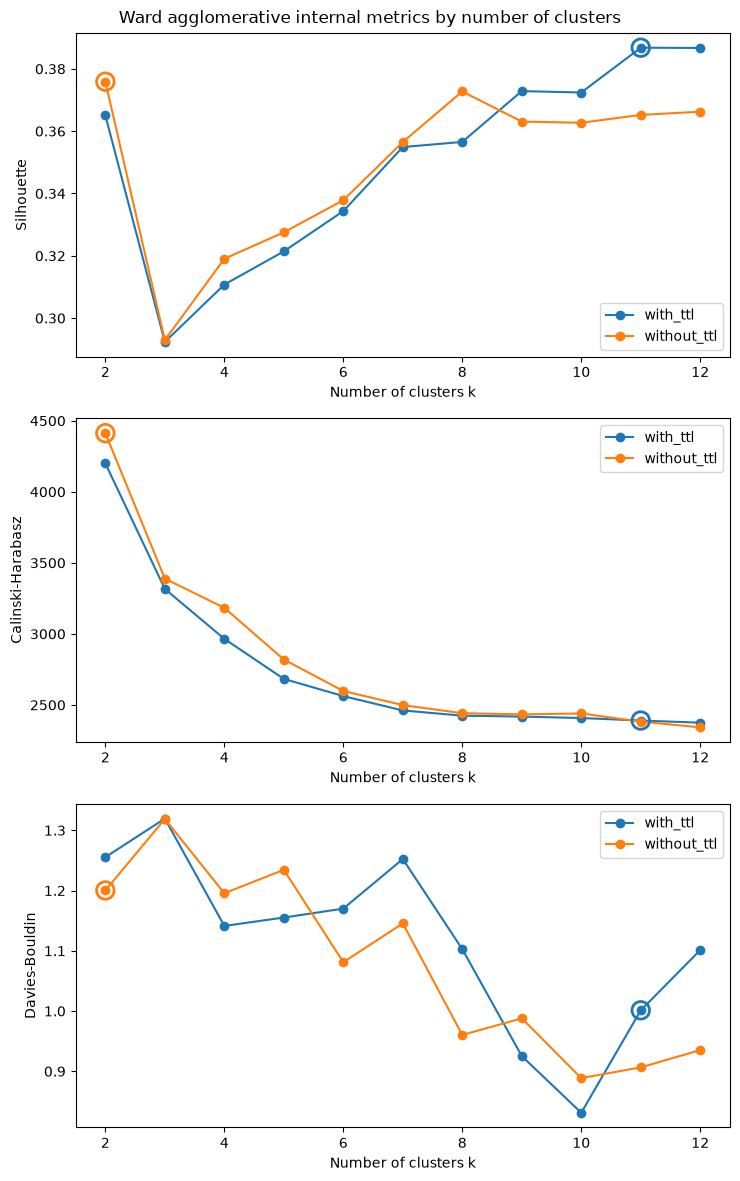

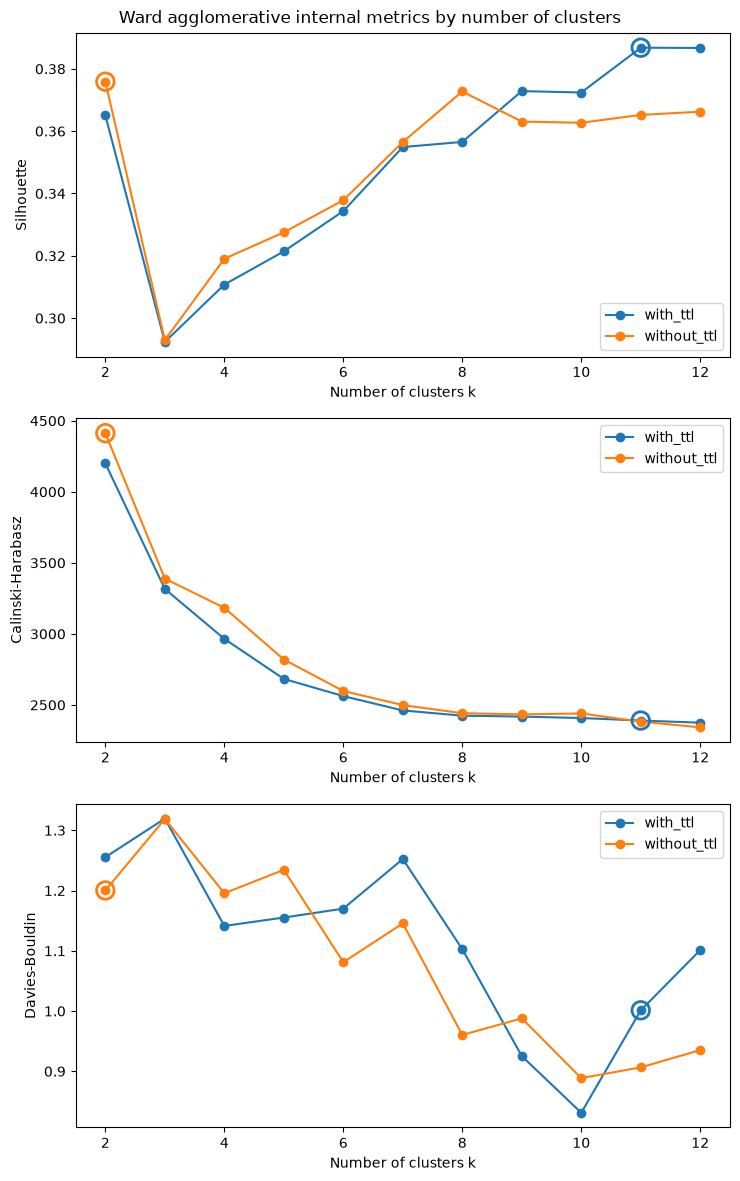

In [19]:
sweep_metrics_figure(
    ward_k_sweep_df,
    ward_k_star,
    "Ward agglomerative internal metrics by number of clusters",
    (
        "Silhouette, Calinski-Harabasz and Davies-Bouldin against k for Ward agglomerative "
        "clustering, both TTL variants; the ringed marker is the selected k*."
    ),
    "ward_internal_metrics_by_k",
)


In [20]:
ward_labels = {v: ward_labels_by_k[v][ward_k_star[v]] for v in VARIANTS}

for v in VARIANTS:
    row = ward_k_sweep_df[
        (ward_k_sweep_df["variant"] == v) & (ward_k_sweep_df["k"] == ward_k_star[v])
    ].iloc[0]
    record_metric(
        f"ward_selected_k_{v}", int(ward_k_star[v]),
        f"Ward k* selected by argmax silhouette for variant {v}.",
    )
    record_metric(
        f"ward_silhouette_at_selected_k_{v}", row["silhouette"],
        f"Ward silhouette at k* for variant {v}.",
    )


## 3. DBSCAN and spectral clustering

DBSCAN's `eps` is chosen deterministically per variant from the normalised-chord knee
of its own sorted k-distance curve (`min_samples = min(2 * d, 50)`, the classic
`2 * dimensionality` rule capped so a ~55-dimensional one-hot space does not demand an
unreasonably large neighbourhood). Spectral clustering runs on a nested 5,000-row
stratified subsample (`affinity="nearest_neighbors"`), using the K-Means `k*` selected
above as its `n_clusters`, since spectral clustering has no internal sweep of its own
in this notebook.


In [21]:
dbscan_min_samples = {}
dbscan_eps = {}
dbscan_rule = {}
dbscan_kdist = {}
for v in VARIANTS:
    min_samples = min(2 * X[v].shape[1], 50)
    eps, rule, kdist = select_eps(X[v], min_samples)
    dbscan_min_samples[v] = min_samples
    dbscan_eps[v] = eps
    dbscan_rule[v] = rule
    dbscan_kdist[v] = kdist

record_note(
    "dbscan_eps_not_transferable",
    "DBSCAN eps and min_samples are selected independently per variant from that "
    "variant's own k-distance curve; the value is not transferable between the "
    "with_ttl and without_ttl feature spaces.",
)


In [22]:
dbscan_parameters_df = pd.DataFrame(
    [
        {
            "variant": v,
            "eps": finite(dbscan_eps[v]),
            "min_samples": int(dbscan_min_samples[v]),
            "rule_used": dbscan_rule[v],
        }
        for v in VARIANTS
    ]
)
writer.add_table(
    dbscan_parameters_df,
    name="dbscan_parameters",
    title="DBSCAN neighbourhood parameters and the rule that selected them",
    description=(
        "eps and min_samples per variant, and the deterministic rule (normalised-chord "
        "knee) used to select eps."
    ),
    sort_by=["variant"],
)


PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/tables/dbscan_parameters.csv')

PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/figures/dbscan_k_distance_plot.png')

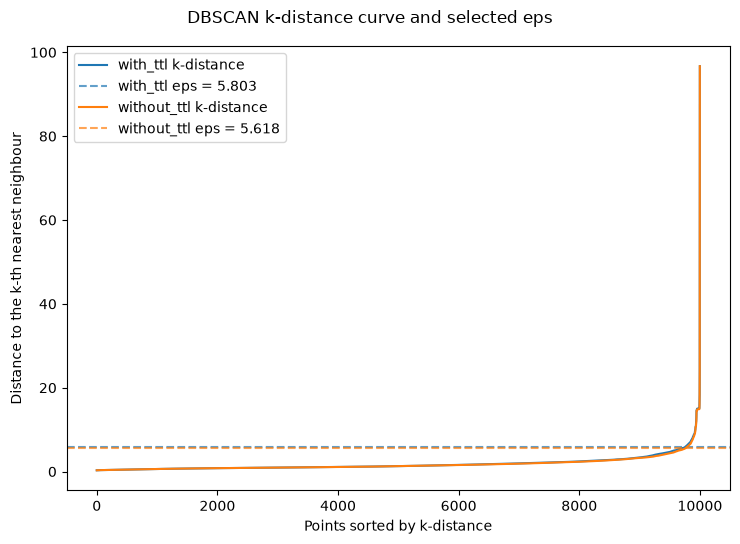

In [23]:
fig, ax = new_figure(nrows=1, ncols=1, figsize=(7.5, 5.5))
for v in VARIANTS:
    kdist = dbscan_kdist[v]
    ax.plot(np.arange(len(kdist)), kdist, label=f"{v} k-distance", color=VARIANT_COLOURS[v])
    ax.axhline(
        dbscan_eps[v], linestyle="--", color=VARIANT_COLOURS[v], alpha=0.7,
        label=f"{v} eps = {dbscan_eps[v]:.3f}",
    )
ax.set_xlabel("Points sorted by k-distance")
ax.set_ylabel("Distance to the k-th nearest neighbour")
ax.legend()
fig.suptitle("DBSCAN k-distance curve and selected eps")
fig.tight_layout()
writer.add_figure(
    fig,
    name="dbscan_k_distance_plot",
    title="DBSCAN k-distance curve and selected eps",
    description=(
        "Sorted k-distance curve per variant with the deterministic normalised-chord "
        "knee eps marked as a dashed line."
    ),
)


In [24]:
dbscan_labels = {}
dbscan_metrics = {}
for v in VARIANTS:
    model = DBSCAN(eps=dbscan_eps[v], min_samples=dbscan_min_samples[v], n_jobs=-1)
    labels = model.fit_predict(X[v])
    dbscan_labels[v] = labels
    dbscan_metrics[v] = internal_metrics(X[v], labels)
    noise_fraction = float((labels == -1).sum() / len(labels))
    cluster_count = int(len(np.unique(labels[labels >= 0])))
    record_metric(
        f"dbscan_cluster_count_{v}", cluster_count,
        f"Number of non-noise DBSCAN clusters for variant {v}.",
    )
    record_metric(
        f"dbscan_noise_fraction_{v}", noise_fraction,
        f"Fraction of points DBSCAN labelled as noise for variant {v}.",
    )
    record_metric(f"dbscan_eps_{v}", dbscan_eps[v], f"Selected DBSCAN eps for variant {v}.")
    record_metric(
        f"dbscan_min_samples_{v}", int(dbscan_min_samples[v]),
        f"DBSCAN min_samples for variant {v}.",
    )


In [25]:
dbscan_cluster_summary_rows = []
for v in VARIANTS:
    labels = dbscan_labels[v]
    unique, counts = np.unique(labels, return_counts=True)
    for cluster, count in zip(unique, counts):
        dbscan_cluster_summary_rows.append({"variant": v, "cluster": int(cluster), "rows": int(count)})

dbscan_cluster_summary_df = pd.DataFrame(dbscan_cluster_summary_rows)
writer.add_table(
    dbscan_cluster_summary_df,
    name="dbscan_cluster_summary",
    title="DBSCAN cluster sizes including the noise label",
    description="Row count per DBSCAN cluster per variant; cluster -1 is the noise label.",
    sort_by=["variant", "cluster"],
)


PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/tables/dbscan_cluster_summary.csv')

In [26]:
spectral_nested = stratified_subsample(
    index_frame, stratify_by="attack_cat", max_rows=SPECTRAL_MAX_ROWS, floor=FLOOR, seed=SEED
)
spectral_positions_all = spectral_nested.data["position"].to_numpy()

spectral_labels = {}
spectral_metrics = {}
for v in VARIANTS:
    model = SpectralClustering(
        n_clusters=k_star[v],
        affinity="nearest_neighbors",
        n_neighbors=10,
        assign_labels="kmeans",
        random_state=SEED,
        n_jobs=-1,
    )
    labels = model.fit_predict(X[v][spectral_positions_all])
    spectral_labels[v] = labels
    spectral_metrics[v] = internal_metrics(X[v][spectral_positions_all], labels)
    record_metric(
        f"spectral_silhouette_{v}", spectral_metrics[v]["silhouette"],
        f"Spectral clustering silhouette for variant {v}, scored on {SPECTRAL_MAX_ROWS} rows.",
    )

spectral_positions = {v: spectral_positions_all for v in VARIANTS}
record_metric(
    "spectral_rows", int(len(spectral_positions_all)),
    "Row count of the nested subsample spectral clustering was fitted and scored on.",
)
record_note(
    "spectral_is_five_thousand_rows",
    f"Spectral clustering runs on a nested {SPECTRAL_MAX_ROWS}-row stratified subsample of "
    f"the {MAX_ROWS}-row analysis population, not the full subsample; its metrics are scored "
    "on those rows only.",
)


/home/pato/Desktop/machine_learning_project/.venv/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


/home/pato/Desktop/machine_learning_project/.venv/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [27]:
spectral_cluster_summary_rows = []
for v in VARIANTS:
    labels = spectral_labels[v]
    unique, counts = np.unique(labels, return_counts=True)
    for cluster, count in zip(unique, counts):
        spectral_cluster_summary_rows.append({"variant": v, "cluster": int(cluster), "rows": int(count)})

spectral_cluster_summary_df = pd.DataFrame(spectral_cluster_summary_rows)
writer.add_table(
    spectral_cluster_summary_df,
    name="spectral_cluster_summary",
    title="Spectral cluster sizes on the 5,000-row subsample",
    description="Row count per spectral cluster per variant, on the nested 5,000-row stratified subsample.",
    sort_by=["variant", "cluster"],
)


PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/tables/spectral_cluster_summary.csv')

PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/figures/spectral_cluster_sizes.png')

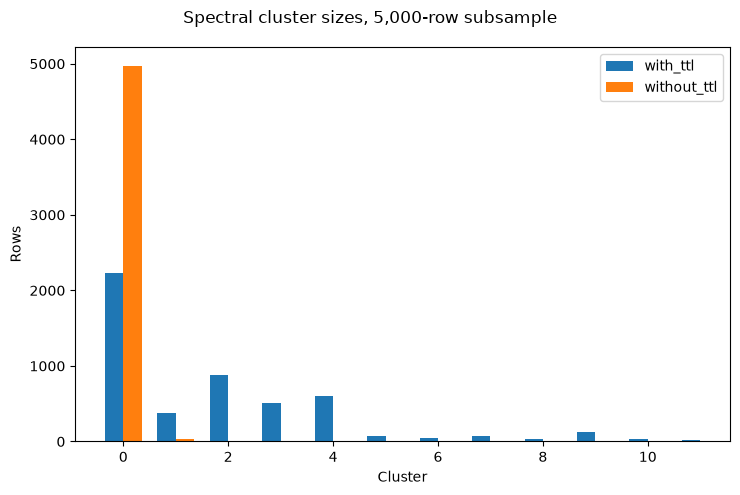

In [28]:
fig, ax = new_figure(nrows=1, ncols=1, figsize=(7.5, 5))
width = 0.35
for offset, v in zip((-width / 2, width / 2), VARIANTS):
    counts = spectral_cluster_summary_df[spectral_cluster_summary_df["variant"] == v].sort_values("cluster")
    ax.bar(counts["cluster"] + offset, counts["rows"], width=width, label=v, color=VARIANT_COLOURS[v])
ax.set_xlabel("Cluster")
ax.set_ylabel("Rows")
ax.legend()
fig.suptitle("Spectral cluster sizes, 5,000-row subsample")
fig.tight_layout()
writer.add_figure(
    fig,
    name="spectral_cluster_sizes",
    title="Spectral cluster sizes, 5,000-row subsample",
    description="Grouped bar chart of spectral cluster sizes per variant on the nested 5,000-row subsample.",
)


In [29]:
method_metrics = {v: {} for v in VARIANTS}
method_labels = {v: {} for v in VARIANTS}
method_positions = {v: {} for v in VARIANTS}
full_positions = np.arange(len(SUB))

for v in VARIANTS:
    kmeans_row = kmeans_k_sweep_df[
        (kmeans_k_sweep_df["variant"] == v) & (kmeans_k_sweep_df["k"] == k_star[v])
    ].iloc[0]
    method_metrics[v]["kmeans"] = {
        "silhouette": kmeans_row["silhouette"],
        "calinski_harabasz": kmeans_row["calinski_harabasz"],
        "davies_bouldin": kmeans_row["davies_bouldin"],
        "n_clusters": kmeans_row["n_clusters"],
        "n_rows_scored": kmeans_row["n_rows_scored"],
    }
    method_labels[v]["kmeans"] = kmeans_labels[v]
    method_positions[v]["kmeans"] = full_positions

    ward_row = ward_k_sweep_df[
        (ward_k_sweep_df["variant"] == v) & (ward_k_sweep_df["k"] == ward_k_star[v])
    ].iloc[0]
    method_metrics[v]["ward"] = {
        "silhouette": ward_row["silhouette"],
        "calinski_harabasz": ward_row["calinski_harabasz"],
        "davies_bouldin": ward_row["davies_bouldin"],
        "n_clusters": ward_row["n_clusters"],
        "n_rows_scored": ward_row["n_rows_scored"],
    }
    method_labels[v]["ward"] = ward_labels[v]
    method_positions[v]["ward"] = ward_rows_positions[v]

    method_metrics[v]["dbscan"] = dbscan_metrics[v]
    method_labels[v]["dbscan"] = dbscan_labels[v]
    method_positions[v]["dbscan"] = full_positions

    method_metrics[v]["spectral"] = spectral_metrics[v]
    method_labels[v]["spectral"] = spectral_labels[v]
    method_positions[v]["spectral"] = spectral_positions[v]

methods_order = ["dbscan", "kmeans", "spectral", "ward"]

internal_metrics_by_method_rows = []
for v in VARIANTS:
    for method in methods_order:
        metrics = method_metrics[v][method]
        internal_metrics_by_method_rows.append(
            {"variant": v, "method": method, **{k: finite(val) for k, val in metrics.items()}}
        )

internal_metrics_by_method_df = pd.DataFrame(internal_metrics_by_method_rows)
writer.add_table(
    internal_metrics_by_method_df,
    name="internal_metrics_by_method",
    title="Internal validation metrics for all four methods",
    description=(
        "Silhouette, Calinski-Harabasz and Davies-Bouldin for each method's selected "
        "clustering, both variants."
    ),
    sort_by=["variant", "method"],
)


PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/tables/internal_metrics_by_method.csv')

PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/figures/internal_metrics_by_method_figure.png')

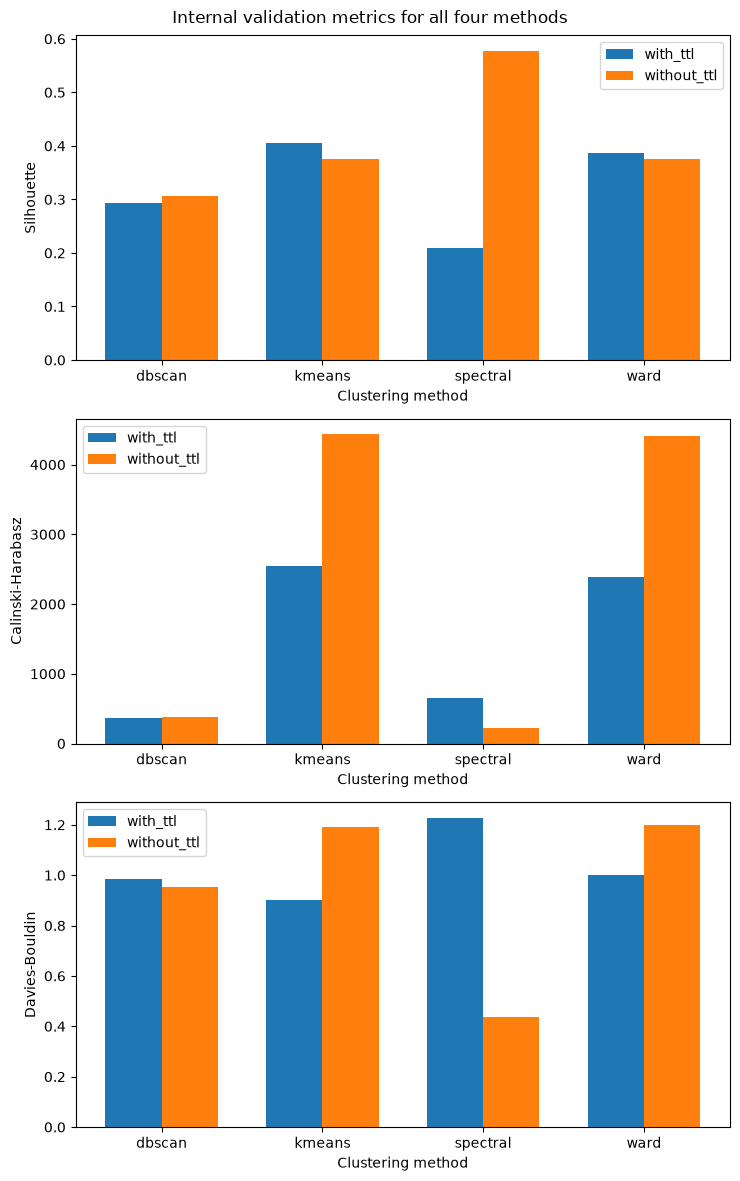

In [30]:
fig, axes = new_figure(nrows=3, ncols=1, figsize=(7.5, 12))
metric_panels = [
    ("silhouette", "Silhouette"),
    ("calinski_harabasz", "Calinski-Harabasz"),
    ("davies_bouldin", "Davies-Bouldin"),
]
x = np.arange(len(methods_order))
width = 0.35
for ax, (column, label) in zip(axes, metric_panels):
    all_values = []
    for offset, v in zip((-width / 2, width / 2), VARIANTS):
        values = [
            method_metrics[v][method][column]
            if isinstance(method_metrics[v][method][column], float)
            else np.nan
            for method in methods_order
        ]
        all_values.extend(val for val in values if np.isfinite(val))
        ax.bar(x + offset, values, width=width, label=v, color=VARIANT_COLOURS[v])
    ax.set_xticks(x)
    ax.set_xticklabels(methods_order)
    ax.set_xlabel("Clustering method")
    ax.set_ylabel(label)
    ax.legend()
    if column == "calinski_harabasz" and all_values and min(all_values) > 0 and max(all_values) / min(all_values) > 100:
        ax.set_yscale("log")
fig.suptitle("Internal validation metrics for all four methods")
fig.tight_layout()
writer.add_figure(
    fig,
    # NOTE: the design's artifact inventory names both the table and this figure
    # "internal_metrics_by_method", but ResultsWriter._register_artifact_name uses one
    # shared name set for tables and figures (src/nids/results.py), so the two cannot
    # share a name. The committed signature wins per the apply instructions; the figure
    # is suffixed "_figure" here and this deviation is recorded in tasks.md.
    name="internal_metrics_by_method_figure",
    title="Internal validation metrics for all four methods",
    description=(
        "Grouped bar chart of silhouette, Calinski-Harabasz and Davies-Bouldin per method "
        "and variant; the Calinski-Harabasz panel uses a log scale when its range exceeds "
        "two orders of magnitude."
    ),
)


In [31]:
def method_sort_key(entry):
    method, metrics = entry
    return _silhouette_sort_key(metrics["silhouette"], method)


best_method = {}
for v in VARIANTS:
    ranked = sorted(method_metrics[v].items(), key=method_sort_key)
    best_method[v] = ranked[0][0]
    record_metric(
        f"best_method_{v}", best_method[v],
        f"Clustering method with the highest silhouette for variant {v} (ties broken by method name ascending).",
    )

best_method


{'with_ttl': 'kmeans', 'without_ttl': 'spectral'}

## 4. Projections to 2D

PCA, t-SNE and UMAP each run **once** per variant on the full 10,000-row subsample and
are reused for both colourings below -- never recomputed. Projections are downstream
of every cluster label; no projection feeds back into any clustering fit.

**Colouring choice:** the "by cluster" panels use the K-Means partition at `k*`,
because it is the only method's labels defined over every one of the 10,000 subsample
rows (spectral clustering only labels its own nested 5,000-row subset, so it cannot
colour the full projection without a shape mismatch). This is stated once here rather
than repeated on each figure.


In [32]:
pca_embed = {}
for v in VARIANTS:
    pca_embed[v] = PCA(n_components=2, random_state=SEED).fit_transform(X[v])


In [33]:
tsne_embed = {}
for v in VARIANTS:
    tsne_embed[v] = TSNE(
        n_components=2, random_state=SEED, init="pca", learning_rate="auto", n_jobs=-1
    ).fit_transform(X[v])


In [34]:
umap_embed = {}
for v in VARIANTS:
    umap_embed[v] = umap.UMAP(n_components=2, random_state=SEED).fit_transform(X[v])


/home/pato/Desktop/machine_learning_project/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/home/pato/Desktop/machine_learning_project/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


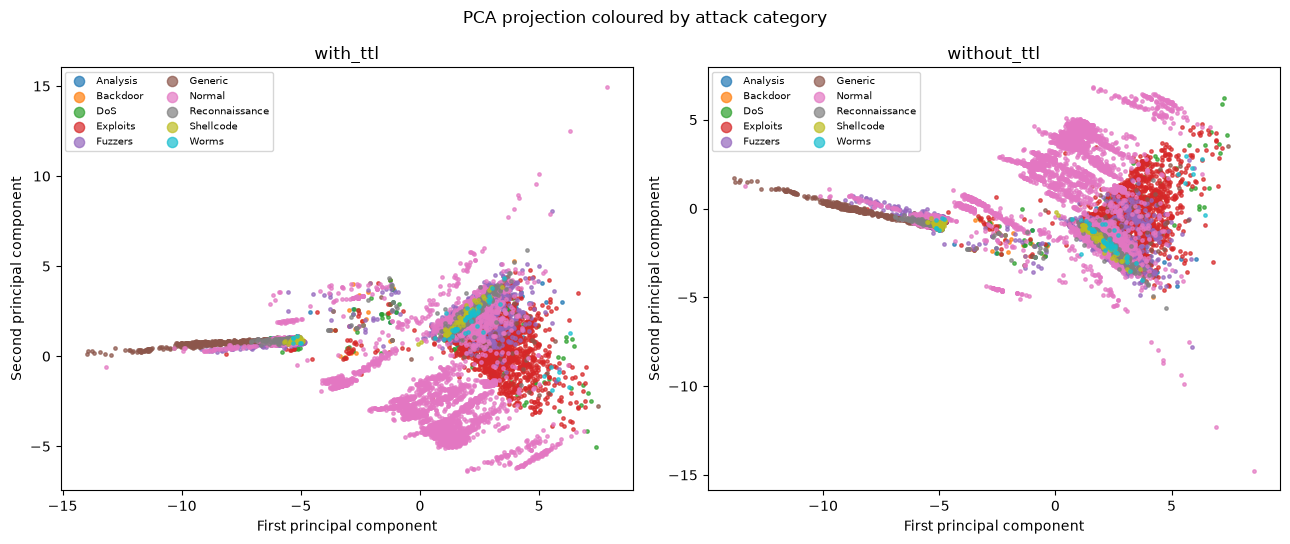

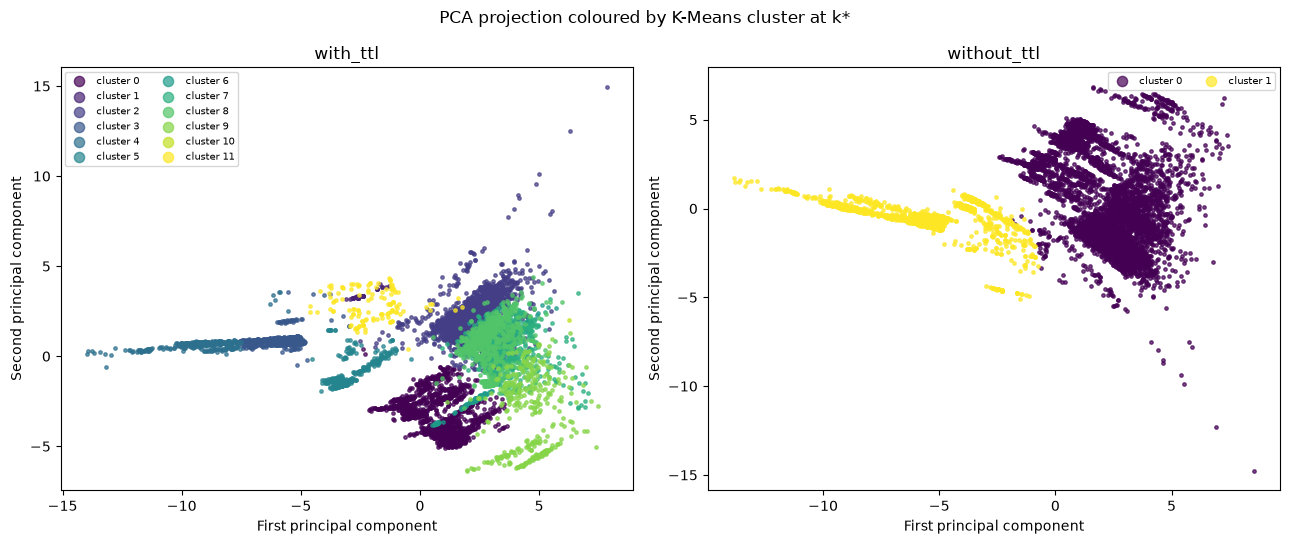

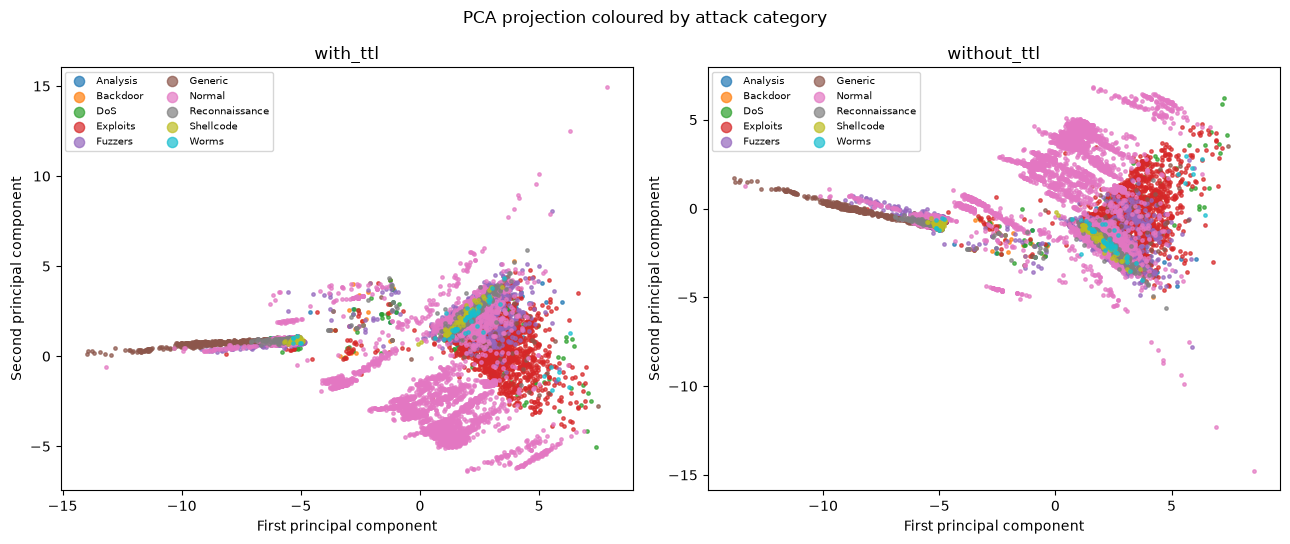

In [35]:
def scatter_by_cluster(embed, labels_by_variant, name, title, xlabel, ylabel, note=""):
    fig, axes = new_figure(nrows=1, ncols=2, figsize=(13, 5.5))
    for ax, v in zip(axes, VARIANTS):
        labels = labels_by_variant[v]
        unique_labels = sorted(int(c) for c in np.unique(labels))
        cmap = plt.get_cmap("viridis")
        for i, cluster in enumerate(unique_labels):
            mask = labels == cluster
            colour = cmap(i / max(len(unique_labels) - 1, 1))
            cluster_label = "noise" if cluster < 0 else f"cluster {cluster}"
            ax.scatter(embed[v][mask, 0], embed[v][mask, 1], s=6, alpha=0.7, color=colour, label=cluster_label)
        ax.set_title(v)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.legend(markerscale=3, fontsize="x-small", ncol=2)
    fig.suptitle(title)
    fig.tight_layout()
    writer.add_figure(fig, name=name, title=title, description=f"{title}. {note}".strip())
    return fig


def scatter_by_attack_cat(embed, name, title, xlabel, ylabel):
    fig, axes = new_figure(nrows=1, ncols=2, figsize=(13, 5.5))
    for ax, v in zip(axes, VARIANTS):
        for cls in _classes_sorted:
            mask = y_cat == cls
            ax.scatter(embed[v][mask, 0], embed[v][mask, 1], s=6, alpha=0.7, color=CLASS_COLOURS[cls], label=cls)
        ax.set_title(v)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.legend(markerscale=3, fontsize="x-small", ncol=2)
    fig.suptitle(title)
    fig.tight_layout()
    writer.add_figure(fig, name=name, title=title, description=title)
    return fig


scatter_by_cluster(
    pca_embed, kmeans_labels, "pca_projection_by_cluster",
    "PCA projection coloured by K-Means cluster at k*",
    "First principal component", "Second principal component",
    note="Coloured by the K-Means partition at k*, which is defined over every subsample row.",
)
scatter_by_attack_cat(
    pca_embed, "pca_projection_by_attack_cat",
    "PCA projection coloured by attack category",
    "First principal component", "Second principal component",
)


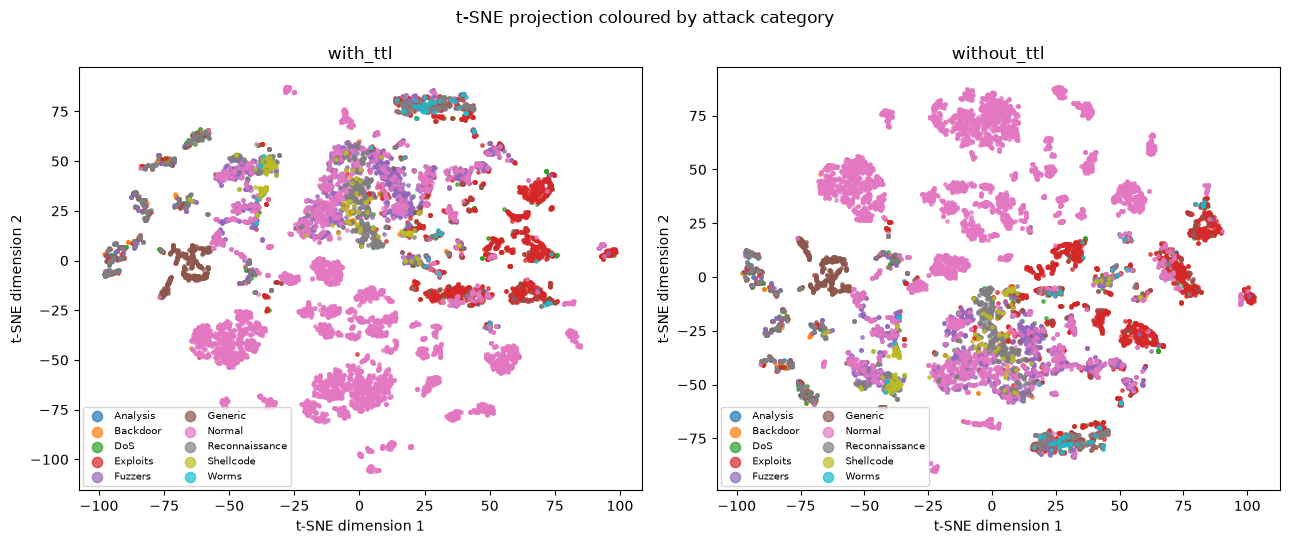

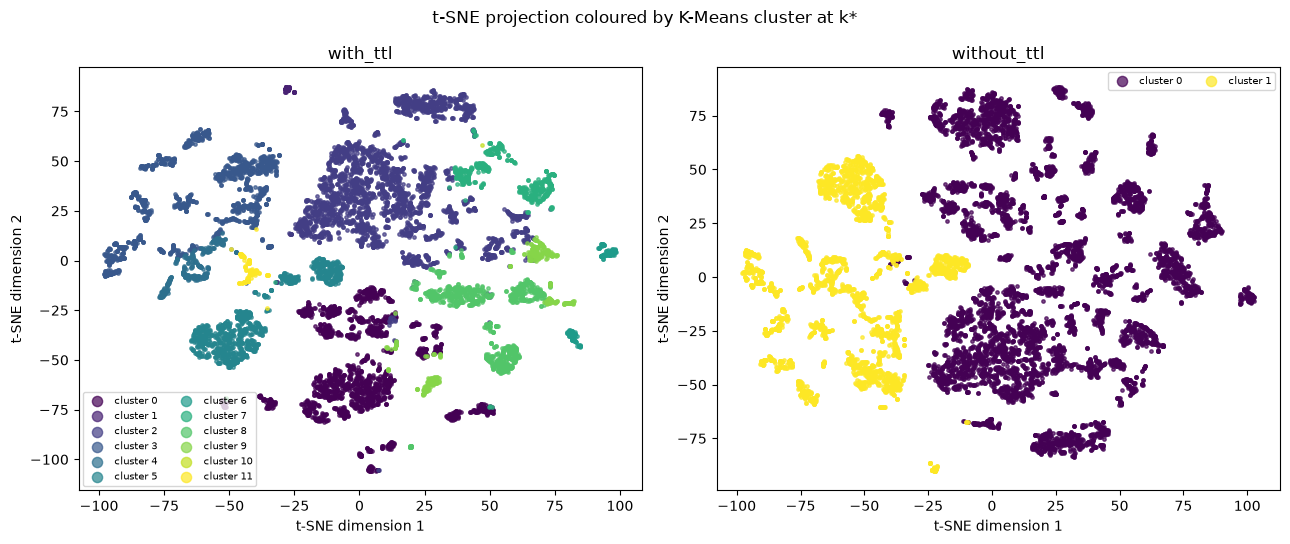

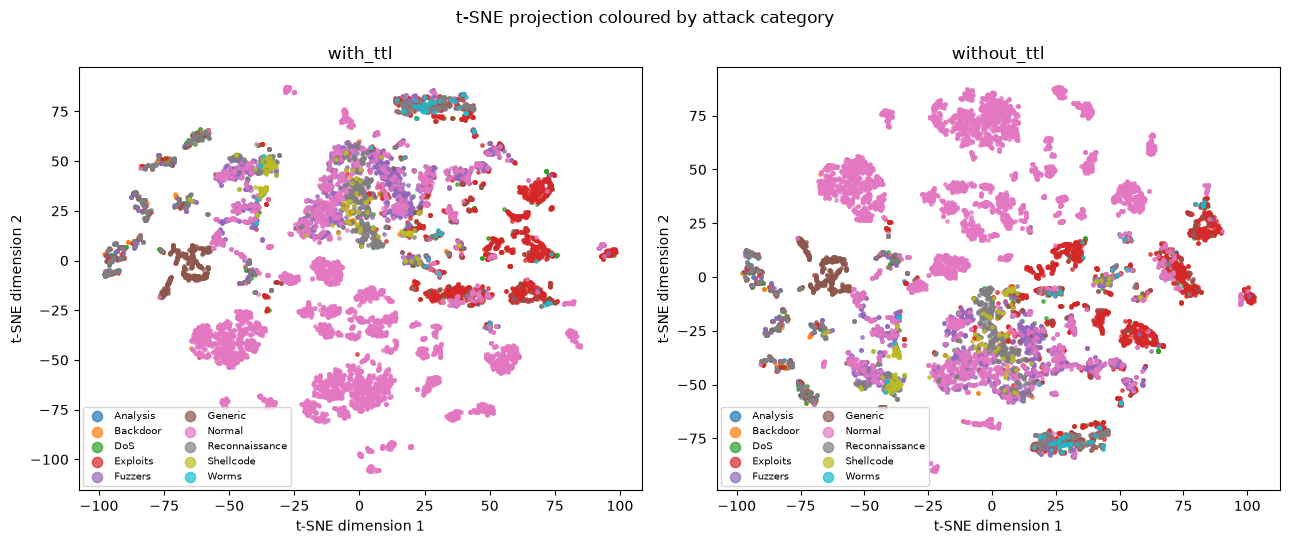

In [36]:
scatter_by_cluster(
    tsne_embed, kmeans_labels, "tsne_projection_by_cluster",
    "t-SNE projection coloured by K-Means cluster at k*",
    "t-SNE dimension 1", "t-SNE dimension 2",
    note="Coloured by the K-Means partition at k*, which is defined over every subsample row.",
)
scatter_by_attack_cat(
    tsne_embed, "tsne_projection_by_attack_cat",
    "t-SNE projection coloured by attack category",
    "t-SNE dimension 1", "t-SNE dimension 2",
)


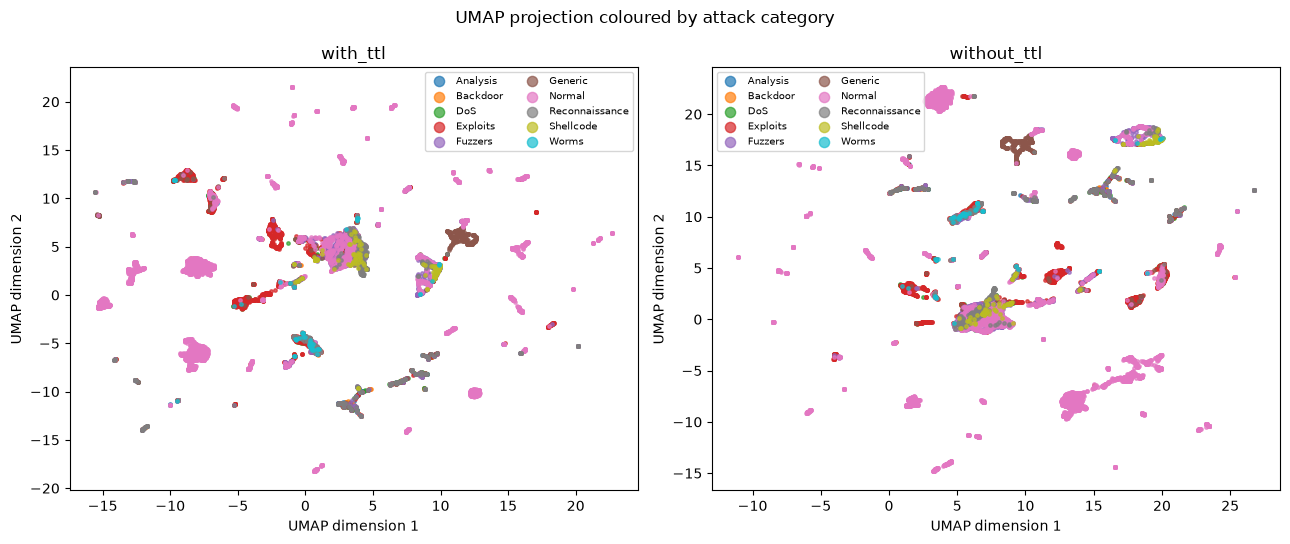

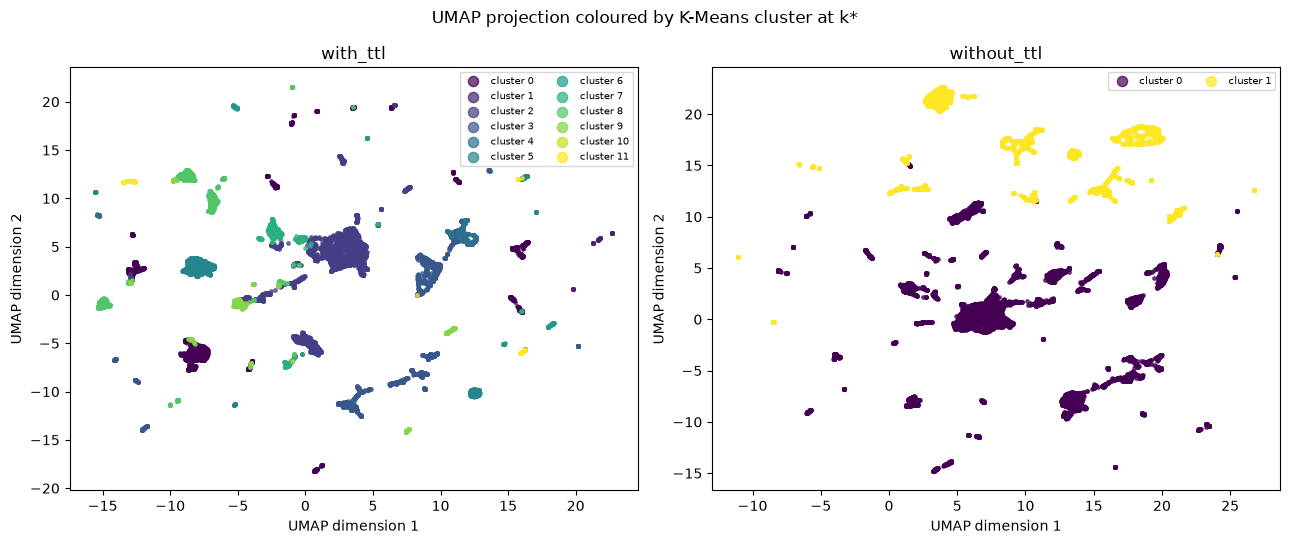

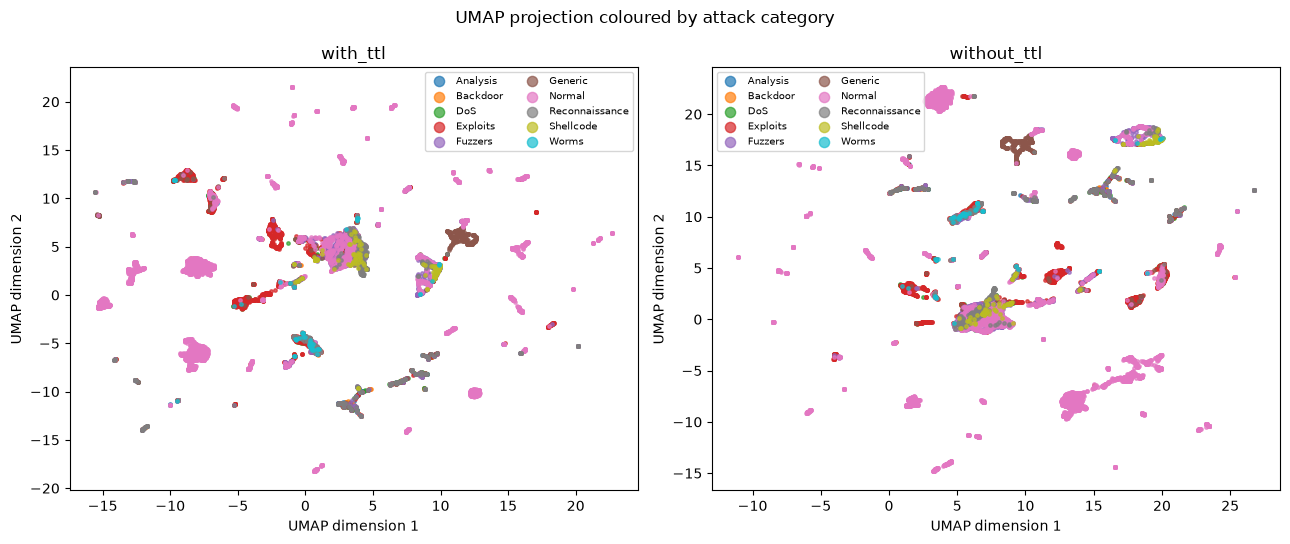

In [37]:
scatter_by_cluster(
    umap_embed, kmeans_labels, "umap_projection_by_cluster",
    "UMAP projection coloured by K-Means cluster at k*",
    "UMAP dimension 1", "UMAP dimension 2",
    note="Coloured by the K-Means partition at k*, which is defined over every subsample row.",
)
scatter_by_attack_cat(
    umap_embed, "umap_projection_by_attack_cat",
    "UMAP projection coloured by attack category",
    "UMAP dimension 1", "UMAP dimension 2",
)


In [38]:
trust_nested = stratified_subsample(
    index_frame, stratify_by="attack_cat", max_rows=TRUSTWORTHINESS_ROWS, floor=FLOOR, seed=SEED
)
trust_positions = trust_nested.data["position"].to_numpy()

projection_trustworthiness_rows = []
embeddings = {"pca": pca_embed, "tsne": tsne_embed, "umap": umap_embed}
for v in VARIANTS:
    for projection_name, embed in embeddings.items():
        score = trustworthiness(X[v][trust_positions], embed[v][trust_positions], n_neighbors=5)
        projection_trustworthiness_rows.append(
            {
                "variant": v,
                "projection": projection_name,
                "trustworthiness": finite(float(score)),
                "n_rows_scored": int(len(trust_positions)),
            }
        )

projection_trustworthiness_df = pd.DataFrame(projection_trustworthiness_rows)
writer.add_table(
    projection_trustworthiness_df,
    name="projection_trustworthiness",
    title="Trustworthiness of each 2D projection",
    description=(
        f"Trustworthiness (n_neighbors=5) of PCA, t-SNE and UMAP against the full feature "
        f"space, on a nested {TRUSTWORTHINESS_ROWS}-row stratified subsample."
    ),
    sort_by=["variant", "projection"],
)


PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/tables/projection_trustworthiness.csv')

## 5. External validation and stability

ARI and NMI compare every method's cluster labels against both `attack_cat` and
`label` -- used here only for this post-hoc comparison, never for any fit. The
contingency table, purity table and heatmap use each variant's **best method**
(highest silhouette, ties broken by method name ascending). Stability always resamples
K-Means at `k*` specifically (not the best method), because K-Means is the one
estimator every variant can refit cheaply on a resampled subset without re-deriving a
linkage matrix, an `eps`, or a nested subsample.


In [39]:
external_validation_rows = []
for v in VARIANTS:
    for method in methods_order:
        positions = method_positions[v][method]
        labels = method_labels[v][method]
        for reference_name, reference_values in (("attack_cat", y_cat), ("label", y_bin)):
            reference_subset = reference_values[positions]
            ari = float(adjusted_rand_score(reference_subset, labels))
            nmi = float(normalized_mutual_info_score(reference_subset, labels))
            external_validation_rows.append(
                {
                    "variant": v, "method": method, "reference": reference_name,
                    "ari": finite(ari), "nmi": finite(nmi),
                }
            )

external_validation_metrics_df = pd.DataFrame(external_validation_rows)
writer.add_table(
    external_validation_metrics_df,
    name="external_validation_metrics",
    title="Adjusted Rand Index and Normalised Mutual Information against both references",
    description=(
        "ARI and NMI of each method's cluster labels against attack_cat and label, both "
        "TTL variants."
    ),
    sort_by=["variant", "method", "reference"],
)

for v in VARIANTS:
    method = best_method[v]
    ari_attack_cat = next(
        row["ari"] for row in external_validation_rows
        if row["variant"] == v and row["method"] == method and row["reference"] == "attack_cat"
    )
    nmi_attack_cat = next(
        row["nmi"] for row in external_validation_rows
        if row["variant"] == v and row["method"] == method and row["reference"] == "attack_cat"
    )
    ari_label = next(
        row["ari"] for row in external_validation_rows
        if row["variant"] == v and row["method"] == method and row["reference"] == "label"
    )
    record_metric(
        f"best_ari_attack_cat_{v}", ari_attack_cat,
        f"ARI against attack_cat for the best method ({method}) in variant {v}.",
    )
    record_metric(
        f"best_nmi_attack_cat_{v}", nmi_attack_cat,
        f"NMI against attack_cat for the best method ({method}) in variant {v}.",
    )
    record_metric(
        f"best_ari_label_{v}", ari_label,
        f"ARI against label for the best method ({method}) in variant {v}.",
    )


PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/figures/external_validation_by_method.png')

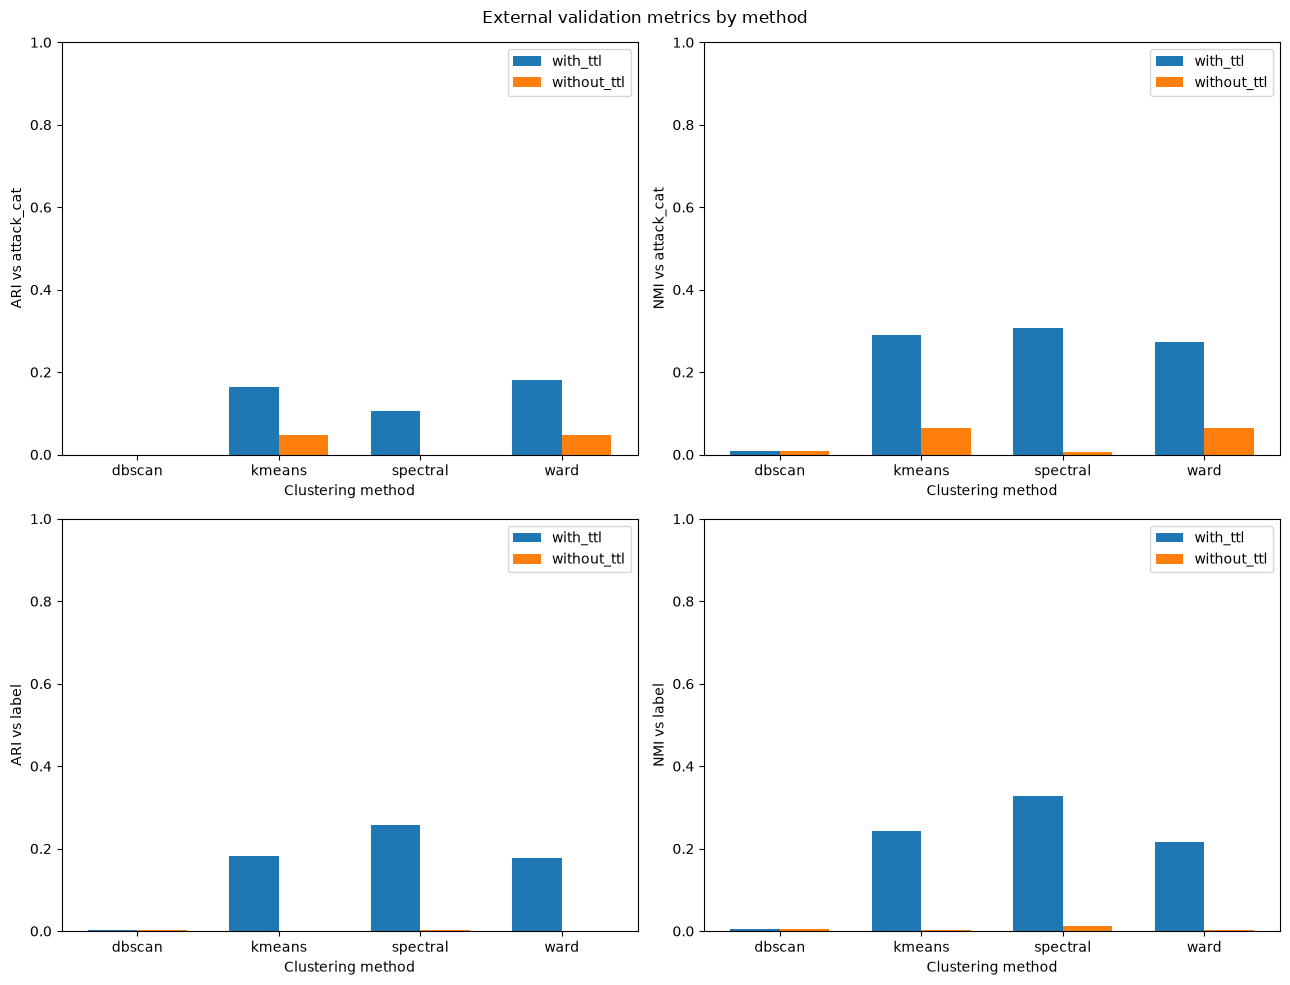

In [40]:
fig, axes = new_figure(nrows=2, ncols=2, figsize=(13, 10))
combos = [("attack_cat", "ari"), ("attack_cat", "nmi"), ("label", "ari"), ("label", "nmi")]
x = np.arange(len(methods_order))
width = 0.35
for ax, (reference, metric_col) in zip(axes.flat, combos):
    for offset, v in zip((-width / 2, width / 2), VARIANTS):
        values = [
            next(
                row[metric_col] for row in external_validation_rows
                if row["variant"] == v and row["method"] == method and row["reference"] == reference
            )
            for method in methods_order
        ]
        values = [val if isinstance(val, float) else np.nan for val in values]
        ax.bar(x + offset, values, width=width, label=v, color=VARIANT_COLOURS[v])
    ax.set_xticks(x)
    ax.set_xticklabels(methods_order)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Clustering method")
    ax.set_ylabel(f"{metric_col.upper()} vs {reference}")
    ax.legend()
fig.suptitle("External validation metrics by method")
fig.tight_layout()
writer.add_figure(
    fig,
    name="external_validation_by_method",
    title="External validation metrics by method",
    description="ARI and NMI against attack_cat and label, grouped by method and variant.",
)


In [41]:
cluster_attack_cat_contingency_rows = []
cluster_attack_cat_purity_rows = []
for v in VARIANTS:
    method = best_method[v]
    positions = method_positions[v][method]
    labels = method_labels[v][method]
    reference_subset = y_cat[positions]
    contingency = pd.crosstab(labels, reference_subset)
    for cluster in contingency.index:
        row_counts = contingency.loc[cluster]
        total = int(row_counts.sum())
        dominant = row_counts.idxmax()
        purity = float(row_counts.max() / total) if total > 0 else float("nan")
        cluster_attack_cat_purity_rows.append(
            {
                "variant": v, "cluster": int(cluster), "dominant_attack_cat": dominant,
                "purity": finite(purity), "cluster_size": total,
            }
        )
        for attack_cat_value in contingency.columns:
            cluster_attack_cat_contingency_rows.append(
                {
                    "variant": v, "cluster": int(cluster), "attack_cat": attack_cat_value,
                    "count": int(contingency.loc[cluster, attack_cat_value]),
                }
            )

cluster_attack_cat_contingency_df = pd.DataFrame(cluster_attack_cat_contingency_rows)
writer.add_table(
    cluster_attack_cat_contingency_df,
    name="cluster_attack_cat_contingency",
    title="Cluster by attack category contingency table for the chosen method",
    description="Row count per (cluster, attack_cat) cell for each variant's best method.",
    sort_by=["variant", "cluster"],
)

cluster_attack_cat_purity_df = pd.DataFrame(cluster_attack_cat_purity_rows)
writer.add_table(
    cluster_attack_cat_purity_df,
    name="cluster_attack_cat_purity",
    title="Dominant attack category and purity per cluster",
    description=(
        "Dominant attack_cat class and its purity fraction per cluster, for each variant's "
        "best method."
    ),
    sort_by=["variant", "cluster"],
)


PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/tables/cluster_attack_cat_purity.csv')

PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/figures/cluster_attack_cat_heatmap.png')

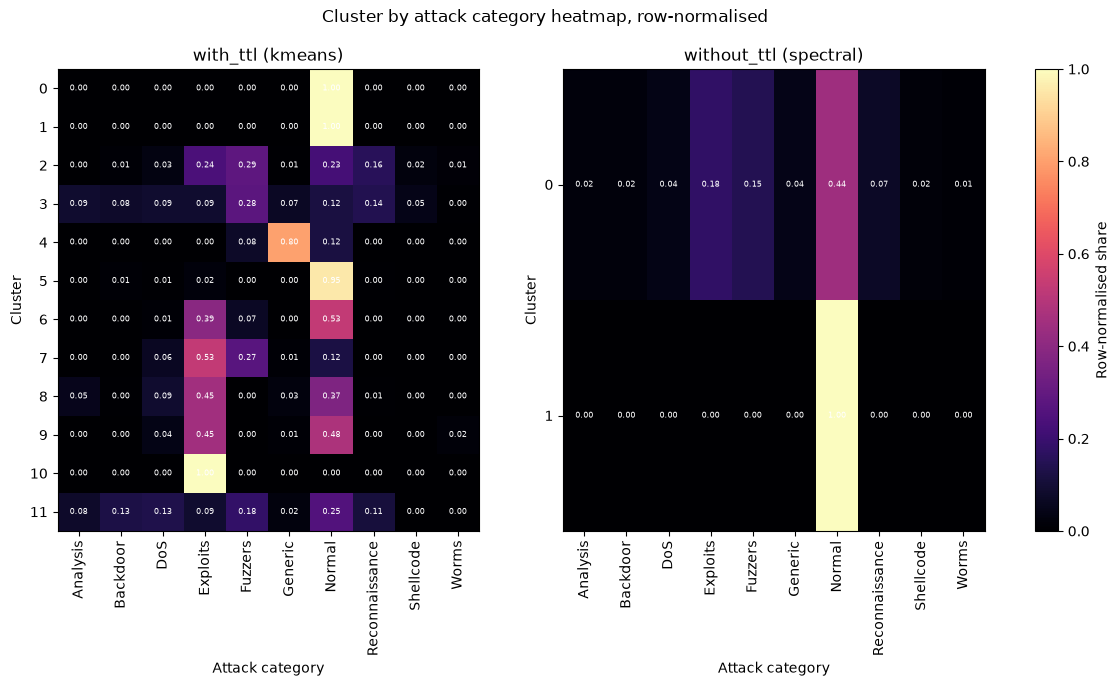

In [42]:
fig, axes = new_figure(nrows=1, ncols=2, figsize=(13, 6))
im = None
for ax, v in zip(axes, VARIANTS):
    variant_df = cluster_attack_cat_contingency_df[cluster_attack_cat_contingency_df["variant"] == v]
    pivot = variant_df.pivot(index="cluster", columns="attack_cat", values="count").fillna(0)
    normalised = pivot.div(pivot.sum(axis=1), axis=0)
    im = ax.imshow(normalised.to_numpy(), cmap="magma", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(normalised.columns)))
    ax.set_xticklabels(normalised.columns, rotation=90)
    ax.set_yticks(range(len(normalised.index)))
    ax.set_yticklabels(normalised.index)
    ax.set_xlabel("Attack category")
    ax.set_ylabel("Cluster")
    ax.set_title(f"{v} ({best_method[v]})")
    for i in range(normalised.shape[0]):
        for j in range(normalised.shape[1]):
            ax.text(j, i, f"{normalised.iat[i, j]:.2f}", ha="center", va="center", color="white", fontsize=6)
fig.colorbar(im, ax=axes, fraction=0.03, label="Row-normalised share")
fig.suptitle("Cluster by attack category heatmap, row-normalised")
writer.add_figure(
    fig,
    name="cluster_attack_cat_heatmap",
    title="Cluster by attack category heatmap, row-normalised",
    description=(
        "Row-normalised heatmap of cluster membership by attack category, for each "
        "variant's best method."
    ),
)


In [43]:
stability_runs = {v: [] for v in VARIANTS}
for v in VARIANTS:
    for r in range(BOOTSTRAP_REPEATS):
        rng = np.random.default_rng(SEED + r)
        rows_r = rng.choice(len(SUB), size=int(BOOTSTRAP_FRACTION * len(SUB)), replace=False)
        model = KMeans(n_clusters=k_star[v], n_init=10, random_state=SEED)
        labels_r = model.fit_predict(X[v][rows_r])
        stability_runs[v].append((rows_r, labels_r))

stability_pairwise_ari_rows = []
for v in VARIANTS:
    runs = stability_runs[v]
    for a in range(BOOTSTRAP_REPEATS):
        for b in range(a + 1, BOOTSTRAP_REPEATS):
            rows_a, labels_a = runs[a]
            rows_b, labels_b = runs[b]
            shared, idx_a, idx_b = np.intersect1d(rows_a, rows_b, return_indices=True)
            if shared.size >= 2:
                ari = float(adjusted_rand_score(labels_a[idx_a], labels_b[idx_b]))
            else:
                ari = float("nan")
            stability_pairwise_ari_rows.append(
                {
                    "variant": v, "run_a": a, "run_b": b,
                    "shared_rows": int(shared.size), "ari": finite(ari),
                }
            )

stability_pairwise_ari_df = pd.DataFrame(stability_pairwise_ari_rows)
writer.add_table(
    stability_pairwise_ari_df,
    name="stability_pairwise_ari",
    title="Pairwise Adjusted Rand Index between bootstrap reruns",
    description=(
        f"ARI between every pair of {BOOTSTRAP_REPEATS} seeded "
        f"{int(BOOTSTRAP_FRACTION * 100)}%-resample K-Means reruns at k*, scored on shared rows."
    ),
    sort_by=["variant", "run_a", "run_b"],
)

stability_summary_rows = []
for v in VARIANTS:
    variant_aris = [
        row["ari"] for row in stability_pairwise_ari_rows
        if row["variant"] == v and isinstance(row["ari"], float)
    ]
    mean_ari = float(np.mean(variant_aris)) if variant_aris else float("nan")
    min_ari = float(np.min(variant_aris)) if variant_aris else float("nan")
    max_ari = float(np.max(variant_aris)) if variant_aris else float("nan")
    stability_summary_rows.append(
        {
            "variant": v, "repeats": BOOTSTRAP_REPEATS,
            "mean_ari": finite(mean_ari), "min_ari": finite(min_ari), "max_ari": finite(max_ari),
        }
    )
    record_metric(
        f"stability_mean_ari_{v}", mean_ari,
        f"Mean pairwise bootstrap ARI for K-Means at k* for variant {v}.",
    )

stability_summary_df = pd.DataFrame(stability_summary_rows)
writer.add_table(
    stability_summary_df,
    name="stability_summary",
    title="Bootstrap stability summary per variant",
    description="Repeat count and the mean, minimum and maximum pairwise ARI across bootstrap reruns.",
    sort_by=["variant"],
)

record_metric(
    "stability_repeats", BOOTSTRAP_REPEATS,
    "Number of seeded bootstrap resamples used for the stability check.",
)


5

PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/figures/stability_ari_distribution.png')

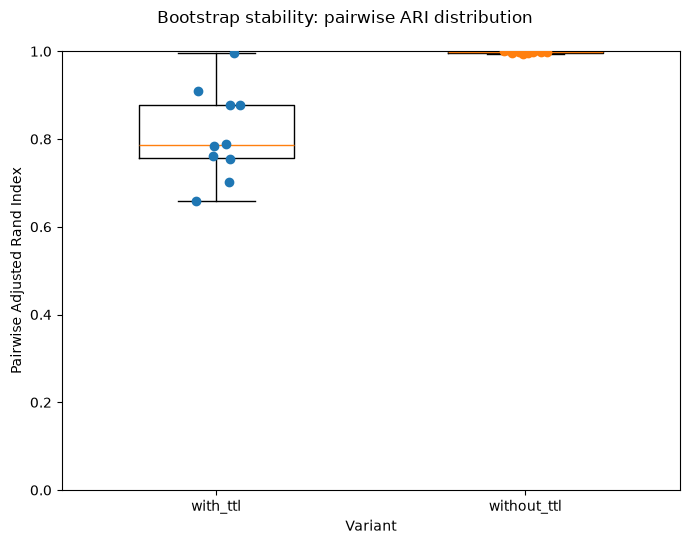

In [44]:
fig, ax = new_figure(nrows=1, ncols=1, figsize=(7, 5.5))
positions = []
data = []
labels_for_axis = []
for i, v in enumerate(VARIANTS):
    variant_aris = [
        row["ari"] for row in stability_pairwise_ari_rows
        if row["variant"] == v and isinstance(row["ari"], float)
    ]
    data.append(variant_aris)
    positions.append(i)
    labels_for_axis.append(v)

ax.boxplot(data, positions=positions, widths=0.5, showfliers=False)
rng = np.random.default_rng(SEED)
for i, variant_aris in enumerate(data):
    jitter = rng.uniform(-0.08, 0.08, size=len(variant_aris))
    ax.scatter(
        np.full(len(variant_aris), i) + jitter, variant_aris,
        color=VARIANT_COLOURS[labels_for_axis[i]], zorder=3,
    )
ax.set_xticks(positions)
ax.set_xticklabels(labels_for_axis)
ax.set_ylim(0, 1)
ax.set_xlabel("Variant")
ax.set_ylabel("Pairwise Adjusted Rand Index")
fig.suptitle("Bootstrap stability: pairwise ARI distribution")
fig.tight_layout()
writer.add_figure(
    fig,
    name="stability_ari_distribution",
    title="Bootstrap stability: pairwise ARI distribution",
    description=(
        "Box plot with jittered points of the 10 pairwise ARI values per variant across 5 "
        "bootstrap reruns."
    ),
)


## 6. Comparison against notebook 01 (reduce-then-cluster)

This section reads `results/eda_reduction_clustering/manifest.json`, produced by the
sibling notebook that reduces first and clusters second, **read-only** and inside a
`try`/`except`. If that file or any metric it needs is missing, the comparison table
still gets built with the missing values marked `"not available"`, a note explains why,
and this notebook continues to completion -- it never raises and it never writes into
notebook 01's folder.


In [45]:
nb1_manifest_path = paths.results_root() / "eda_reduction_clustering" / "manifest.json"
nb1_available = nb1_manifest_path.is_file()
metrics_nb1 = {}
nb1_unavailable_reason = None

if nb1_available:
    try:
        nb1_payload = json.loads(nb1_manifest_path.read_text(encoding="utf-8"))
        metrics_nb1 = {entry["name"]: entry["value"] for entry in nb1_payload.get("metrics", [])}
    except (json.JSONDecodeError, KeyError, OSError) as error:
        nb1_available = False
        nb1_unavailable_reason = f"{type(error).__name__}: {error}"

if not nb1_available and nb1_unavailable_reason is None:
    nb1_unavailable_reason = "results/eda_reduction_clustering/manifest.json does not exist yet."

record_metric(
    "notebook_01_comparison_available", "yes" if nb1_available else "no",
    "Whether notebook 01's manifest.json was readable when this notebook ran.",
)

if not nb1_available:
    print(
        "Notebook 01 has not produced results/eda_reduction_clustering/manifest.json yet; "
        "run notebook 01 and re-execute this notebook to populate the comparison."
    )


In [46]:
def nb1_metric(name):
    return metrics_nb1.get(name, "not available")


pipeline_comparison_rows = []
for v in VARIANTS:
    cluster_then_reduce = {
        "selected_k": k_star[v],
        "silhouette_at_selected_k": metrics_log.get(f"kmeans_silhouette_at_selected_k_{v}", "not available"),
    }
    reduce_then_cluster = {
        "selected_k": nb1_metric(f"kmeans_selected_k_{v}"),
        "silhouette_at_selected_k": nb1_metric(f"kmeans_silhouette_at_selected_k_{v}"),
    }
    for metric_name in ("selected_k", "silhouette_at_selected_k"):
        pipeline_comparison_rows.append(
            {"pipeline": "cluster_then_reduce", "variant": v, "metric": metric_name, "value": cluster_then_reduce[metric_name]}
        )
        pipeline_comparison_rows.append(
            {"pipeline": "reduce_then_cluster", "variant": v, "metric": metric_name, "value": reduce_then_cluster[metric_name]}
        )

pipeline_comparison_df = pd.DataFrame(pipeline_comparison_rows)
writer.add_table(
    pipeline_comparison_df,
    name="pipeline_comparison",
    title="Reduce-then-cluster against cluster-then-reduce on shared metrics",
    description=(
        "K-Means selected k and its silhouette, this notebook (cluster-then-reduce) against "
        "notebook 01 (reduce-then-cluster), where available."
    ),
    sort_by=["pipeline", "variant", "metric"],
)

record_note(
    "comparison_is_not_controlled",
    "Notebook 01 clusters the full partition in PCA-90 space with silhouette measured on a "
    "subsample; this notebook clusters a 10,000-row subsample in the full feature space with "
    "silhouette measured on the same rows. Different populations, different spaces -- the "
    "comparison is directional evidence, not a controlled experiment.",
)

if not nb1_available:
    record_note(
        "notebook_01_comparison_unavailable",
        f"Notebook 01's results were not available ({nb1_unavailable_reason}). Run notebook 01, "
        "then re-execute notebooks/02_clustering_reduction.ipynb to populate the comparison.",
    )


PosixPath('/home/pato/Desktop/machine_learning_project/results/clustering_reduction/figures/pipeline_comparison_metrics.png')

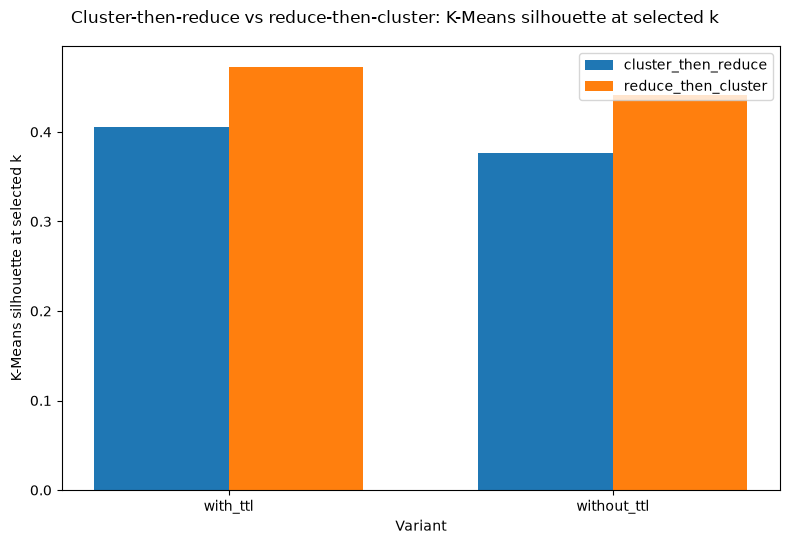

In [47]:
fig, ax = new_figure(nrows=1, ncols=1, figsize=(8, 5.5))
if not nb1_available:
    ax.axis("off")
    ax.text(0.5, 0.5, "Notebook 01 results not available", ha="center", va="center", fontsize=14)
else:
    plot_df = pipeline_comparison_df[pipeline_comparison_df["metric"] == "silhouette_at_selected_k"].copy()
    plot_df["value_numeric"] = pd.to_numeric(plot_df["value"], errors="coerce")
    x = np.arange(len(VARIANTS))
    width = 0.35
    for offset, pipeline in zip((-width / 2, width / 2), ("cluster_then_reduce", "reduce_then_cluster")):
        values = [
            plot_df[(plot_df["variant"] == v) & (plot_df["pipeline"] == pipeline)]["value_numeric"].iloc[0]
            for v in VARIANTS
        ]
        ax.bar(x + offset, values, width=width, label=pipeline)
    ax.set_xticks(x)
    ax.set_xticklabels(VARIANTS)
    ax.set_xlabel("Variant")
    ax.set_ylabel("K-Means silhouette at selected k")
    ax.legend()
fig.suptitle("Cluster-then-reduce vs reduce-then-cluster: K-Means silhouette at selected k")
fig.tight_layout()
writer.add_figure(
    fig,
    name="pipeline_comparison_metrics",
    title="Cluster-then-reduce vs reduce-then-cluster: K-Means silhouette at selected k",
    description=(
        "Grouped bars comparing this notebook's cluster-then-reduce silhouette against "
        "notebook 01's reduce-then-cluster silhouette, or a single annotation when notebook "
        "01 has not run."
    ),
)


## 7. TTL-shortcut deltas, conclusions and limitations

`sttl` and `ct_state_ttl` are the known UNSW-NB15 testbed shortcut (AGENTS.md). The
cell below states, in plain English, every place where dropping them changes a
*conclusion* (which method wins, which k is selected) rather than only a number.


In [48]:
def describe_delta(label, with_value, without_value):
    if not (isinstance(with_value, float) and isinstance(without_value, float)):
        return f"- {label}: with_ttl={with_value}, without_ttl={without_value} (non-numeric, no delta computed)."
    delta = without_value - with_value
    return f"- {label}: with_ttl={with_value:.4f}, without_ttl={without_value:.4f}, delta={delta:+.4f}."


print("TTL-shortcut delta report (without_ttl minus with_ttl):\n")
print(describe_delta(
    "K-Means silhouette at k*",
    metrics_log["kmeans_silhouette_at_selected_k_with_ttl"],
    metrics_log["kmeans_silhouette_at_selected_k_without_ttl"],
))
print(describe_delta(
    "Best-method ARI vs attack_cat",
    metrics_log["best_ari_attack_cat_with_ttl"],
    metrics_log["best_ari_attack_cat_without_ttl"],
))
print(describe_delta(
    "Best-method NMI vs attack_cat",
    metrics_log["best_nmi_attack_cat_with_ttl"],
    metrics_log["best_nmi_attack_cat_without_ttl"],
))
print(f"- K-Means selected k*: with_ttl={k_star['with_ttl']}, without_ttl={k_star['without_ttl']}.")
print(f"- Ward selected k*: with_ttl={ward_k_star['with_ttl']}, without_ttl={ward_k_star['without_ttl']}.")

if best_method["with_ttl"] != best_method["without_ttl"]:
    print(
        f"- Best method changes when sttl/ct_state_ttl are dropped: "
        f"{best_method['with_ttl']} (with_ttl) -> {best_method['without_ttl']} (without_ttl). "
        "This is a conclusion-level change, not only a numeric one."
    )
else:
    print(
        f"- Best method stays {best_method['with_ttl']} in both variants; dropping "
        "sttl/ct_state_ttl only shifts the numbers above."
    )


TTL-shortcut delta report (without_ttl minus with_ttl):

- K-Means silhouette at k*: with_ttl=0.4053, without_ttl=0.3762, delta=-0.0290.
- Best-method ARI vs attack_cat: with_ttl=0.1633, without_ttl=-0.0053, delta=-0.1686.
- Best-method NMI vs attack_cat: with_ttl=0.2889, without_ttl=0.0051, delta=-0.2838.
- K-Means selected k*: with_ttl=12, without_ttl=2.
- Ward selected k*: with_ttl=11, without_ttl=2.
- Best method changes when sttl/ct_state_ttl are dropped: kmeans (with_ttl) -> spectral (without_ttl). This is a conclusion-level change, not only a numeric one.


In [49]:
record_note(
    "targets_never_fitted",
    "attack_cat and label are used only for subsample stratification, figure colouring, and "
    "post-hoc external validation (ARI, NMI, contingency); they never reach a fit, "
    "fit_transform or fit_predict call.",
)
record_note(
    "test_partition_never_loaded",
    "This notebook loads only the cleaned training partition "
    "(nids.data.load_clean_partitions().train). No name in its global namespace ever refers "
    "to the cleaned testing partition, enforced by an assertion cell.",
)
record_note(
    "subsample_is_the_analysis_population",
    f"Every clustering, projection and stability computation runs on the seed-{SEED} "
    f"stratified subsample (at most {MAX_ROWS} rows, floor {FLOOR}). The subsample is the "
    "analysis population itself, not an estimate of a full-partition quantity.",
)
record_note(
    "infinite_metrics_as_string",
    "Any non-finite metric value (infinite or NaN) is registered as the string 'inf', '-inf' "
    "or 'nan' instead of a floating-point value, because JSON has no native representation "
    "for infinity or NaN.",
)


In [50]:
runtime_seconds_total = time.time() - START_TIME
record_metric(
    "runtime_seconds_total", runtime_seconds_total,
    "Wall-clock seconds from the first config cell to this cell.",
)
print(f"Runtime so far: {runtime_seconds_total:.1f} seconds.")


Runtime so far: 93.6 seconds.


In [51]:
counts_payload = {entry.name: entry.value for entry in writer.metrics}
writer.write_json(counts_payload, name="counts")
output_directory = writer.close()
print("Manifest written to:", output_directory / "manifest.json")
print("Notebook 02 (cluster-then-reduce) finished.")


Manifest written to: /home/pato/Desktop/machine_learning_project/results/clustering_reduction/manifest.json
Notebook 02 (cluster-then-reduce) finished.
